## Purpose: 
To Manually go through and inspect the outputs of the code that was generated by ChatGPT and Claude in the script structural_maps.py

In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize

from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser

#### Step 1: Build MALDI data 
##### - High level overview
Build maldi data, reads the imzml path and extracts all x & y coordinates, intensities, and mzs into their own respective array. As its extracting the data we apply filtering conditions such as min_intensitiy and min_count. It also calculates grid shape (H, W) and not sure exactly why that is....

It also contains 4 helper functions: dense_mz_bins, denoise components (this can already be taken out....was not a fan), compute_structural_field(), combine_component_structural_field() 

In [2]:
def dense_mz_bins(mzs: np.ndarray,
                  intensities: np.ndarray,
                  pixel_indices: np.ndarray,
                  mz_tol: float,
                  min_count: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Assign m/z values to dense-region bins using the DBSCAN-like 1D rule.

    Bins are contiguous sorted regions whose min_count-ahead m/z difference is
    below mz_tol. Sparse/noise regions and bins with fewer than min_count values
    are removed.
    """
    if min_count < 1:
        raise ValueError("min_count must be at least 1")

    order = np.argsort(mzs)
    sorted_mzs = mzs[order]
    sorted_intensities = intensities[order]
    sorted_pixel_indices = pixel_indices[order]
    n_values = len(sorted_mzs)

    if n_values <= min_count:
        return (
            np.array([], dtype=sorted_mzs.dtype),
            np.array([], dtype=sorted_intensities.dtype),
            np.array([], dtype=sorted_pixel_indices.dtype),
            np.array([], dtype=np.int64),
        )

    delta_values = -1 * sorted_mzs[:(n_values - min_count)] + sorted_mzs[min_count:n_values]
    delta_mz = np.concatenate([delta_values, np.zeros(min_count, dtype=sorted_mzs.dtype)])
    in_dense_region = (delta_mz < mz_tol).astype(np.int64)

    difference = np.diff(in_dense_region)
    difference_plus = np.maximum(difference, 0)
    running_bin_nr = np.cumsum(difference_plus)

    delta = in_dense_region
    bin_nr = delta[:-1] * running_bin_nr
    bin_labels = np.concatenate([[delta[0]], bin_nr]).astype(np.int64)

    keep = bin_labels != 0
    if not np.any(keep):
        return (
            np.array([], dtype=sorted_mzs.dtype),
            np.array([], dtype=sorted_intensities.dtype),
            np.array([], dtype=sorted_pixel_indices.dtype),
            np.array([], dtype=np.int64),
        )

    sorted_mzs = sorted_mzs[keep]
    sorted_intensities = sorted_intensities[keep]
    sorted_pixel_indices = sorted_pixel_indices[keep]
    bin_labels = bin_labels[keep]

    labels, counts = np.unique(bin_labels, return_counts=True)
    dense_labels = labels[counts >= min_count]
    keep = np.isin(bin_labels, dense_labels)

    return (
        sorted_mzs[keep],
        sorted_intensities[keep],
        sorted_pixel_indices[keep],
        bin_labels[keep],
    )

##### MALDI Data Processing and NMF Decomposition. 

In [3]:

"""
Load MSI, run NMF, and build structural fields for registration.

Returns dict with:
    components      [K, H, W] float32, raw per-component normalized [0, 1]
    denoised_components [K, H, W] float32, denoised components normalized [0, 1]
    structural_fields dict of MALDI edge/orientation/anisotropy/vesselness
    registration_image [H, W] selected structural field for registration
    component_spectra [K, n_bins] float32 - the H matrix of NMF
    mz_axis         [n_bins] float32 - bin-center m/z values
    pixel_size_um   float - physical size of one MALDI pixel
    grid_shape      (H, W)
    n_components    K
    grid_origin     (x0, y0) - offset of MALDI grid origin in imzML coords
"""
imzml_path = "/home/kia/MALDI_Metabolomics/MSI_data_grant/Mass_Spec_data/20251012_old_liver_profiles.imzML"
pixel_size_um = 5
mz_bin_width = 0.042
mz_bin_min_count = 10
n_components = 5
#denoise_method = "gaussian"
#gaussian_sigma = 1.0
#median_radius = 1
min_intensity = 10
parser = ImzMLParser(imzml_path)
coords_list = list(parser.coordinates)
xs = np.array([c[0] for c in coords_list])
ys = np.array([c[1] for c in coords_list])
x0, y0 = int(xs.min()), int(ys.min())
H = int(ys.max() - y0 + 1)
W = int(xs.max() - x0 + 1)
n_px = len(coords_list)
print(f"[1/7] Loaded {n_px} spectra | grid {H}×{W} | {pixel_size_um} μm/pixel")

# First pass -- collect intensity-filtered peaks for dense m/z binning.
all_mzs = []
all_intensities = []
all_pixel_indices = []
for idx in range(n_px):
    mzs, ints = parser.getspectrum(idx)
    m = ints > min_intensity
    if m.any():
        all_mzs.append(mzs[m].astype(np.float64, copy=False))
        all_intensities.append(ints[m].astype(np.float32, copy=False))
        all_pixel_indices.append(np.full(int(m.sum()), idx, dtype=np.int64))
if not all_mzs:
    raise RuntimeError("No spectra survived intensity threshold")

all_mzs = np.concatenate(all_mzs)
all_intensities = np.concatenate(all_intensities)
all_pixel_indices = np.concatenate(all_pixel_indices)
mz_min = float(all_mzs.min())
mz_max = float(all_mzs.max())
print(
    f"[1/7] m/z [{mz_min:.2f}, {mz_max:.2f}] | "
    f"dense bin tolerance {mz_bin_width} Da | min_count={mz_bin_min_count}"
)
print(f"[1/7] collected {len(all_mzs):,} peaks above intensity {min_intensity}")
print(f"all_intensities: {all_intensities[:4]}, \n all_pixel_indices: {all_pixel_indices[:4]}")
binned_mzs, binned_intensities, binned_pixel_indices, bin_labels = dense_mz_bins(
    all_mzs,
    all_intensities,
    all_pixel_indices,
    mz_tol=mz_bin_width,
    min_count=mz_bin_min_count,
)
if len(bin_labels) == 0:
    raise RuntimeError(
        "Dense m/z binning produced no bins. Try increasing --mz_bin or "
        "lowering --mz_bin_min_count."
    )
print(f"binned_mzs,  {binned_mzs[:4]}, \nbinned_intensities: {binned_intensities[:4]}, \nbinned_pixel_indices: {binned_pixel_indices[:4]}, \nbin_labels: {bin_labels[:4]}")
unique_bin_labels, bin_index = np.unique(bin_labels, return_inverse=True)
n_bins = len(unique_bin_labels)

bin_centers = np.bincount(bin_index, weights=binned_mzs) / np.bincount(bin_index)
print(f"[1/7] Dense m/z binning kept {len(binned_mzs):,} values in {n_bins} bins")

# Fill the [n_pixels, n_bins] matrix.
X = np.zeros((n_px, n_bins), dtype=np.float32) # n_pix are the number of coordinates, n_bins unique m/z bins
np.add.at(X, (binned_pixel_indices, bin_index), binned_intensities) # fast way to make spot x feature matrix

# Drop empty bins (saves memory and speeds up NMF)
nonzero = X.sum(axis=0) > 0
X = X[:, nonzero]
bin_centers = bin_centers[nonzero]
print(f"[1/7] Spectral matrix: {X.shape}")
print(f'display of X[:4, :4]: {X[:4, :4]}')

# NMF
print(f"[2/7] NMF with k={n_components}")
model = NMF(n_components=n_components, init="nndsvda",
            max_iter=500, random_state=42)
W_mat = model.fit_transform(X)
print(f"[2/7] NMF reconstruction error: {model.reconstruction_err_:.3f}")

# Build per-component images, normalize each to [0, 1]
# This is building the components into images, can be plotted by plt.imshow(comp_imgs[k], cmap="viridis")
comp_imgs = np.zeros((n_components, H, W), dtype=np.float32)
rows = np.array([int(c[1] - y0) for c in coords_list], dtype=int)
cols = np.array([int(c[0] - x0) for c in coords_list], dtype=int)
for k in range(n_components):
    c = W_mat[:, k]
    c = c / (c.max() + 1e-8)
    comp_imgs[k, rows, cols] = c

print(f"[2/7] skipping denoising")

"""
print(f"[2/7] Computing MALDI structural fields from {n_components} NMF components")
component_fields = [
    compute_structural_fields(denoised_comp_imgs[k])
    for k in range(n_components)
]
structural_fields = combine_component_structural_fields(
    component_fields, method=structural_combine)
if registration_field not in structural_fields or registration_field == "orientation":
    raise ValueError("registration_field must be 'edge', 'anisotropy', or 'vesselness'")
"""

/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[1/7] Loaded 269511 spectra | grid 713×787 | 5 μm/pixel
[1/7] m/z [61.99, 514.29] | dense bin tolerance 0.042 Da | min_count=10
[1/7] collected 16,950,072 peaks above intensity 10
all_intensities: [1069.5298     15.84879    43.751095   29.167397], 
 all_pixel_indices: [0 0 0 0]
binned_mzs,  [61.98658258 62.96241416 62.96241416 62.96241416], 
binned_intensities: [11.322993  10.148849  10.673888  10.8845415], 
binned_pixel_indices: [ 86576 104080  86637 143155], 
bin_labels: [1 1 1 1]
[1/7] Dense m/z binning kept 16,946,826 values in 281 bins
[1/7] Spectral matrix: (269511, 281)
display of X[:4, :4]: [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[2/7] NMF with k=5


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[2/7] NMF reconstruction error: 39389.559
[2/7] skipping denoising


'\nprint(f"[2/7] Computing MALDI structural fields from {n_components} NMF components")\ncomponent_fields = [\n    compute_structural_fields(denoised_comp_imgs[k])\n    for k in range(n_components)\n]\nstructural_fields = combine_component_structural_fields(\n    component_fields, method=structural_combine)\nif registration_field not in structural_fields or registration_field == "orientation":\n    raise ValueError("registration_field must be \'edge\', \'anisotropy\', or \'vesselness\'")\n'

In [4]:
comp_imgs.shape

(5, 713, 787)

comp_imgs is the tensor that contains all of the NMF components of the MALDI after standard normalization

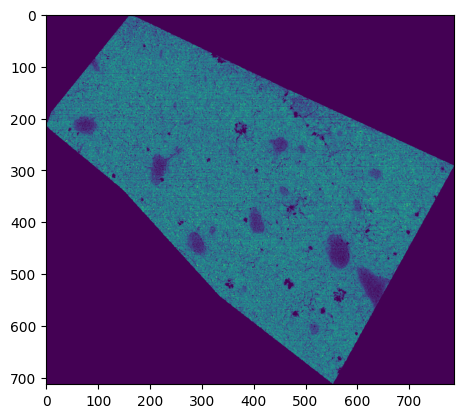

In [5]:
plt.imshow(comp_imgs[0], cmap="viridis")
plt.show()

#### Step 1a: compute_structural_fields()

place holder for what th

In [6]:
def normalize01(arr: np.ndarray) -> np.ndarray:
    arr = arr.astype(np.float32, copy=False)
    lo = float(np.nanmin(arr))
    hi = float(np.nanmax(arr))
    if hi > lo:
        return ((arr - lo) / (hi - lo)).astype(np.float32)
    return np.zeros_like(arr, dtype=np.float32)

def robust_normalize01(arr: np.ndarray,
                       lower: float = 1.0,
                       upper: float = 99.0) -> np.ndarray:
    """Percentile-normalize one image so outliers do not set the full scale."""
    arr = arr.astype(np.float32, copy=False)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return np.zeros_like(arr, dtype=np.float32)
    lo, hi = np.percentile(finite, [lower, upper])
    if hi <= lo:
        return normalize01(arr)
    return np.clip((arr - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)

##### Testing the normalization between edges and orientation images 

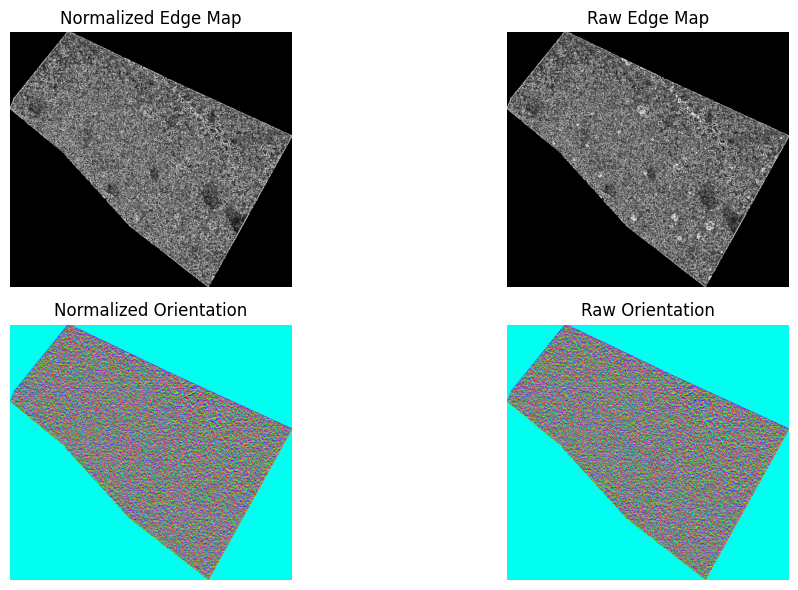

In [7]:

"""
Convert one image into structural fields.

The fields describe tissue geometry rather than raw intensity:
    edge        Sobel gradient magnitude
    orientation undirected local gradient angle in radians
    anisotropy  structure-tensor coherence, high for oriented structures
    vesselness  Frangi response for line/vessel-like structures
"""


# for now we say that an image is just one of the nmf components. 
image = comp_imgs[4] # just take the first component for now, could be made into a loop or something to compute fields for all components.

norm_img = robust_normalize01(image) # I really am just warry  of this function normalizing is nice, but I want to be sure it is not doing anything weird to the data. I guess I could test it on some synthetic data.
gy_norm, gx_norm = np.gradient(norm_img)
edge_norm = robust_normalize01(sobel(norm_img))
orientation_norm = np.arctan2(gy_norm, gx_norm).astype(np.float32)

# repeat without normalization to see the difference
gy, gx = np.gradient(image)
edge = robust_normalize01(sobel(image))
orientation = np.arctan2(gy, gx).astype(np.float32)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# --- Row 1: Edge maps ---
axes[0, 0].imshow(edge_norm, cmap="gray")
axes[0, 0].set_title("Normalized Edge Map")
axes[0, 0].axis("off")

axes[0, 1].imshow(edge, cmap="gray")
axes[0, 1].set_title("Raw Edge Map")
axes[0, 1].axis("off")

# --- Row 2: Orientation maps ---
im = axes[1, 0].imshow(orientation_norm, cmap="hsv")
axes[1, 0].set_title("Normalized Orientation")
axes[1, 0].axis("off")

axes[1, 1].imshow(orientation, cmap="hsv")
axes[1, 1].set_title("Raw Orientation")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


It sounds like the orientation measures the pixel graident. So which direction the intensity is changing, across every pixel. 
Strucutre tensor's encode structural features on a pixel neighborhood basis defined by sigma (default is sigma=1 we should increase this to see how the tensors change) 

Anisotropy is a measure of coherence for the structural tensor which is 


$$
\mathbf{J}(x,y) =
G_{\sigma} *
\begin{bmatrix}
I_x^2 & I_x I_y \\
I_x I_y & I_y^2
\end{bmatrix}
$$

Where:

$$
\mathbf{J}(x,y) = \text{structure tensor at pixel } (x,y)
$$

$$
G_{\sigma} = \text{Gaussian smoothing kernel with standard deviation } \sigma
$$

$$
I_x = \frac{\partial I}{\partial x} = \text{image intensity gradient in the } x \text{-direction}
$$

$$
I_y = \frac{\partial I}{\partial y} = \text{image intensity gradient in the } y \text{-direction}
$$

$$
I(x,y) = \text{image intensity at pixel } (x,y)
$$

it is a measure of how direction of the gradient changes, so if the ansitropy of the region is low then you can assume that area is mostly uniform. i.e) Tells you how strongly the local neighborhood prefers one dominant direction and is defined as: 

$$
\mathrm{Anisotropy} =
\frac{\lambda_1 - \lambda_2}
{\lambda_1 + \lambda_2}
$$

Where:

$$
\lambda_1 = \text{large eigenvalue of the structure tensor}
$$

$$
\lambda_2 = \text{small eigenvalue}
$$

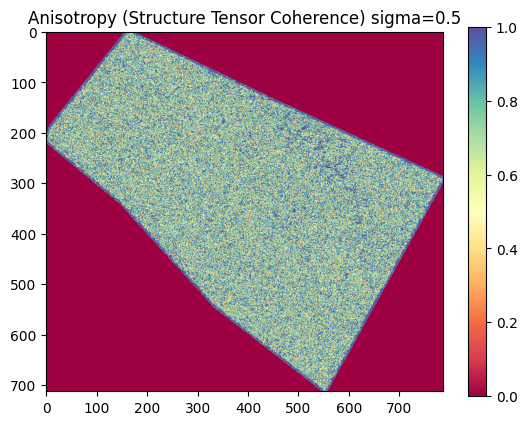

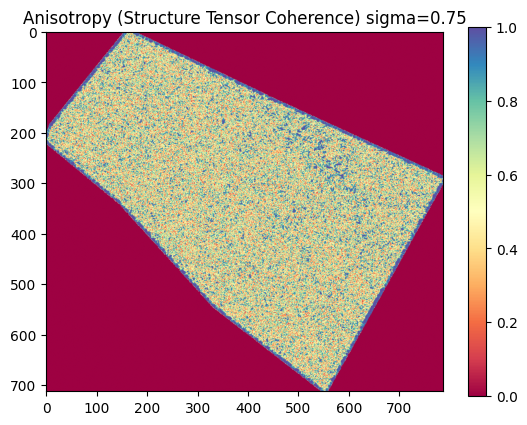

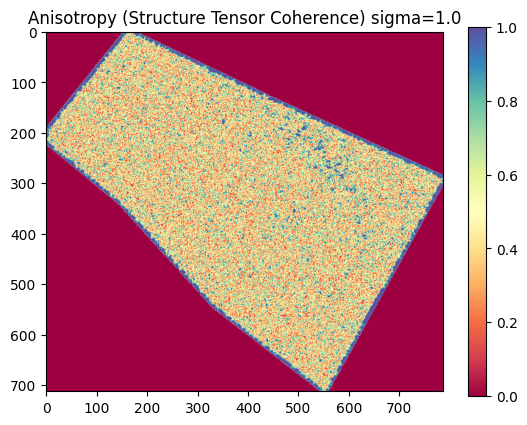

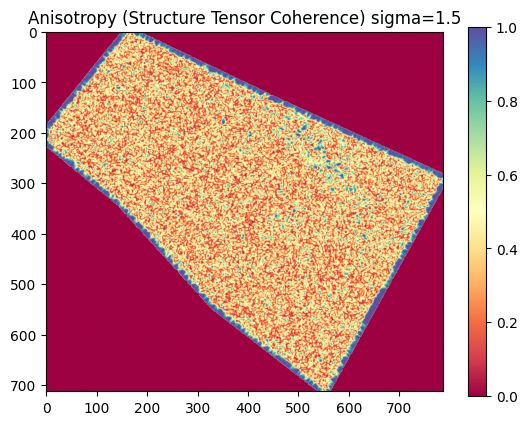

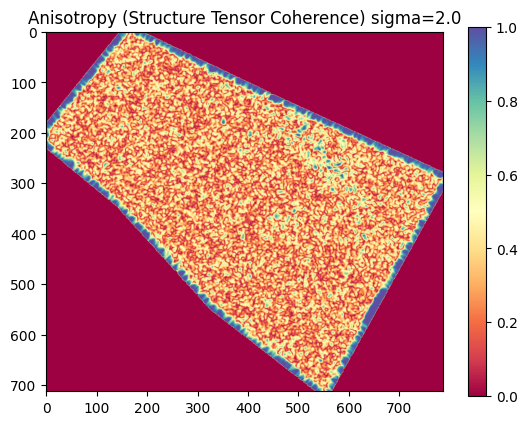

In [8]:
tensor_sigma = [0.5, 0.75, 1.0, 1.5, 2.0]
for sigma in tensor_sigma:
    Axx, Axy, Ayy = structure_tensor(norm_img, sigma=sigma)
    trace = Axx + Ayy
    det_term = np.sqrt(np.maximum((Axx - Ayy) ** 2 + 4.0 * Axy ** 2, 0.0))
    lambda1 = 0.5 * (trace + det_term)
    lambda2 = 0.5 * (trace - det_term)
    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)
    anisotropy = robust_normalize01(anisotropy)

    # H&E vessels may appear dark while MALDI line-like structures can be
    # bright or dark depending on component polarity, so keep the stronger
    # response from both ridge assumptions.
    plt.imshow(anisotropy, cmap="Spectral")
    plt.title(f"Anisotropy (Structure Tensor Coherence) sigma={sigma}")
    plt.colorbar()
    plt.show()

Looking at the anisotropy it doesnt look like it really gives good detection of the local vessel strucutures I will come back to this with the structure tensor eigenvalues and see what they show for the local orientation...but first check out the frangi vessels 

In [9]:
np.unique(lambda1) # this is a spots x feature array, where the feature is the largest structure tensor eigenvalue at each pixel. 
#                   It is interesting that there are only 3 unique values, which suggests that many pixels have identical structure 
#                   tensor properties. This could be due to the nature of the image or the way the structure tensor is computed.

array([0.0000000e+00, 1.2804979e-17, 3.1378918e-17, ..., 5.4535074e+00,
       5.4718838e+00, 5.4911652e+00], shape=(293068,), dtype=float32)

Frangi vessels is a vessel filter that determines ridge like structures (literally meant to identify vessels). It essentially looks at the curvature of the intensity by taking the eigenvalues of the hessian matrix. The eigenvalues tell us which directions the brightness drops off therefore finding the borders of the vessles. It also applies a gaussian smoothing in a sense to find the size of the vessels. Some formulas for chatgpt...

$$
\textbf{Constructing the Hessian Matrix}
$$

For a 2D image at a given scale $\sigma$, the Hessian matrix $\mathbf{H}$ is a $2 \times 2$ matrix of second-order spatial derivatives evaluated at each pixel coordinate:

$$
\mathbf{H} =
\begin{bmatrix}
L_{xx} & L_{xy} \\
L_{yx} & L_{yy}
\end{bmatrix}
=
\begin{bmatrix}
I * \frac{\partial^2 G}{\partial x^2} &
I * \frac{\partial^2 G}{\partial x \partial y} \\
I * \frac{\partial^2 G}{\partial y \partial x} &
I * \frac{\partial^2 G}{\partial y^2}
\end{bmatrix}
$$

Where:

$$
\mathbf{H} = \text{Hessian matrix describing local second-order image curvature}
$$

$$
L_{xx} = I * \frac{\partial^2 G}{\partial x^2}
= \text{second derivative response in the } x \text{-direction}
$$

$$
L_{yy} = I * \frac{\partial^2 G}{\partial y^2}
= \text{second derivative response in the } y \text{-direction}
$$

$$
L_{xy}, L_{yx}
= \text{mixed second derivative responses}
$$

$$
I = \text{input image intensity function}
$$

$$
G = \text{Gaussian kernel}
$$

$$
\sigma = \text{Gaussian scale parameter controlling observation scale}
$$

$$
* = \text{convolution operator}
$$

$$
x,y = \text{spatial image coordinates}
$$


alpha=0.5, beta=0.5, gamma=0.5 -> min 0.0000, max 1.0000, mean 0.1103
alpha=0.5, beta=0.5, gamma=1.0 -> min 0.0000, max 1.0000, mean 0.1086
alpha=1.0, beta=0.5, gamma=0.5 -> min 0.0000, max 1.0000, mean 0.1103
alpha=1.0, beta=1.0, gamma=1.0 -> min 0.0000, max 1.0000, mean 0.1166


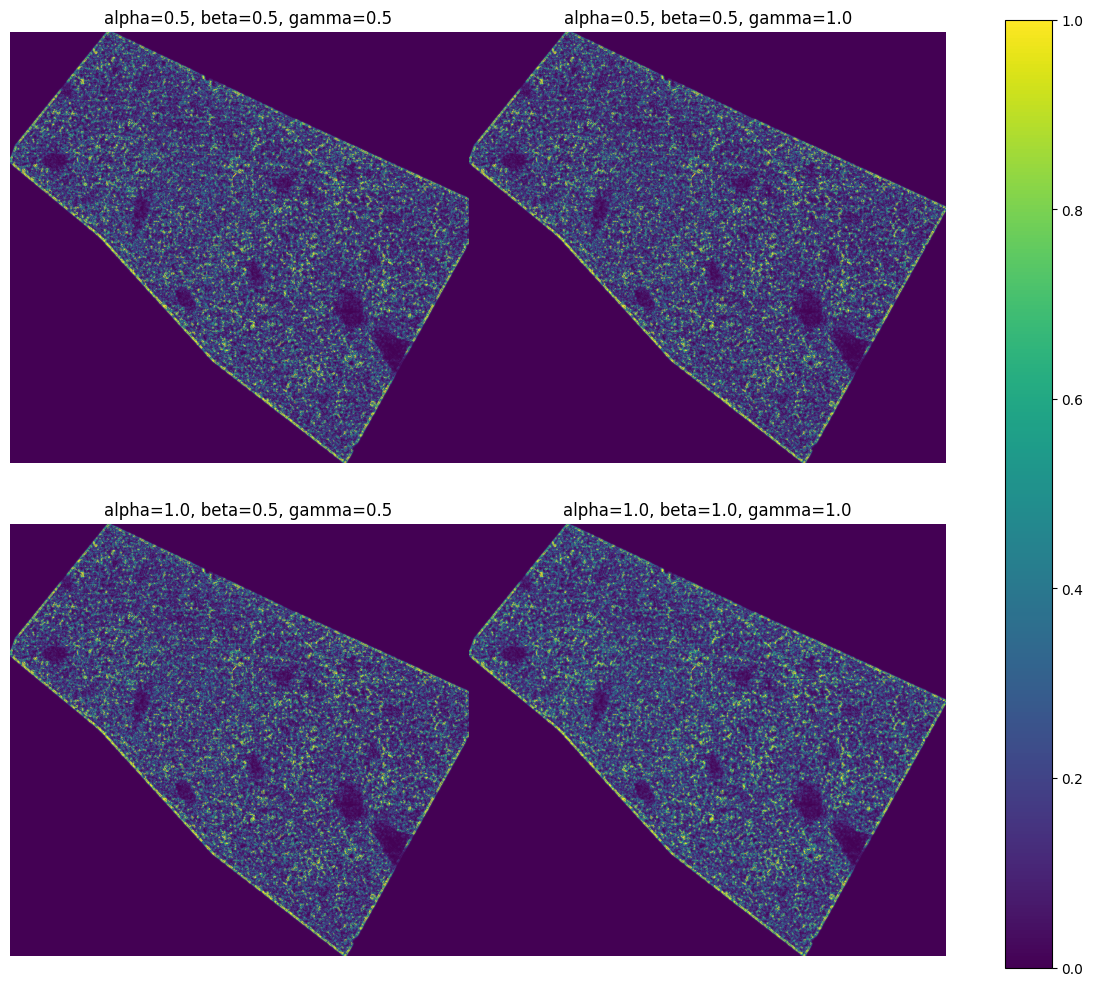

In [10]:
frangi_sigmas = [0.25,0.5, 0.75, 1.0, 1.5, 2.0]
param_grid = [
    {"alpha": 0.5, "beta": 0.5, "gamma": 0.5},
    {"alpha": 0.5, "beta": 0.5, "gamma": 1.0},
    {"alpha": 1.0, "beta": 0.5, "gamma": 0.5},
    {"alpha": 1.0, "beta": 1.0, "gamma": 1.0},
]
norm_img = robust_normalize01(comp_imgs[0]) # just take the first component for now, could be made into a loop or something to compute fields for all components.
vesselness_results = {}
for params in param_grid:
    alpha = params["alpha"]
    beta = params["beta"]
    gamma = params["gamma"]

    vessel_bright = frangi(
        norm_img,
        sigmas=frangi_sigmas,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        black_ridges=False,
    )
    vessel_dark = frangi(
        norm_img,
        sigmas=frangi_sigmas,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        black_ridges=True,
    )
    vesselness = robust_normalize01(np.maximum(vessel_bright, vessel_dark))
    key = f"alpha={alpha}, beta={beta}, gamma={gamma}"
    vesselness_results[key] = vesselness

    print(
        f"{key} -> min {vesselness.min():.4f}, max {vesselness.max():.4f}, "
        f"mean {vesselness.mean():.4f}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (key, vesselness) in zip(axes, vesselness_results.items()):
    ax.imshow(vesselness, cmap="viridis")
    ax.set_title(key)
    ax.axis("off")

plt.tight_layout()
plt.colorbar(ax.imshow(vesselness, cmap="viridis"), ax=axes.ravel().tolist())
plt.show()

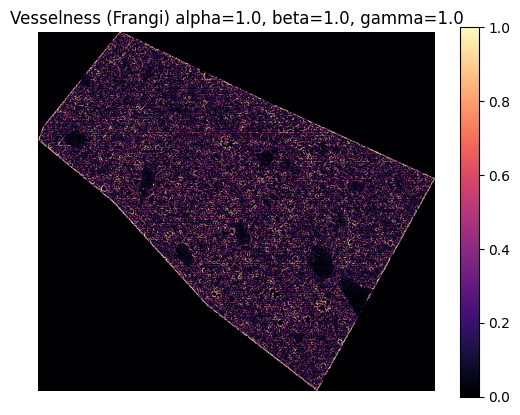

In [11]:
#
"""
vessel_bright = frangi(
    img,
    sigmas=frangi_sigmas,
    alpha=FRANGI_ALPHA,
    beta=FRANGI_BETA,
    gamma=FRANGI_GAMMA,
    black_ridges=False,
)
"""
# Play around with the vesselness parameters to see how they affect the result. The Frangi filter is designed to enhance 
# line-like structures, and the parameters alpha, beta, and gamma control the sensitivity to different types of structures. 
# By adjusting these parameters, you can see how the vesselness response changes for bright and dark ridges in the image.
FRANGI_ALPHA = 1.0
FRANGI_BETA = 1.0
FRANGI_GAMMA = 1.0
vessel_dark = frangi(
    norm_img,
    sigmas=frangi_sigmas,
    alpha=FRANGI_ALPHA,
    beta=FRANGI_BETA,
    gamma=FRANGI_GAMMA,
    black_ridges=False,
)
vesselness = robust_normalize01(np.maximum(vessel_bright, vessel_dark))
plt.imshow(vesselness, cmap="magma")
plt.colorbar()
plt.title(f"Vesselness (Frangi) alpha={FRANGI_ALPHA}, beta={FRANGI_BETA}, gamma={FRANGI_GAMMA}")
plt.axis("off")
plt.show()
# end of compute structural_fields()

dict_keys(['edge', 'orientation', 'anisotropy', 'vesselness'])


(np.float64(-0.5), np.float64(786.5), np.float64(712.5), np.float64(-0.5))

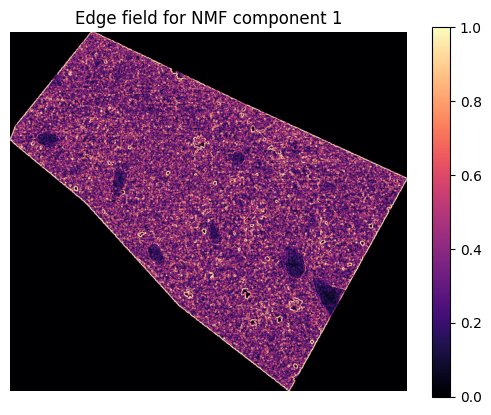

In [12]:
STRUCTURE_TENSOR_SIGMA = 1.0
FRANGI_SIGMAS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
FRANGI_ALPHA = 1.0
FRANGI_BETA = 1.0
FRANGI_GAMMA = 1.0  
def compute_structural_fields(image: np.ndarray,
                              tensor_sigma: float = STRUCTURE_TENSOR_SIGMA,
                              frangi_sigmas: tuple = FRANGI_SIGMAS) -> dict:
    """
    Convert one image into structural fields.

    The fields describe tissue geometry rather than raw intensity:
      edge        Sobel gradient magnitude
      orientation undirected local gradient angle in radians
      anisotropy  structure-tensor coherence, high for oriented structures
      vesselness  Frangi response for line/vessel-like structures
    """
    img = robust_normalize01(image)
    gy, gx = np.gradient(img)
    edge = robust_normalize01(sobel(img))
    orientation = np.arctan2(gy, gx).astype(np.float32)

    Axx, Axy, Ayy = structure_tensor(img, sigma=tensor_sigma)
    trace = Axx + Ayy
    det_term = np.sqrt(np.maximum((Axx - Ayy) ** 2 + 4.0 * Axy ** 2, 0.0))
    lambda1 = 0.5 * (trace + det_term)
    lambda2 = 0.5 * (trace - det_term)
    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)
    anisotropy = robust_normalize01(anisotropy)

    # H&E vessels may appear dark while MALDI line-like structures can be
    # bright or dark depending on component polarity, so keep the stronger
    # response from both ridge assumptions.
    vessel_bright = frangi(
        img,
        sigmas=frangi_sigmas,
        alpha=FRANGI_ALPHA,
        beta=FRANGI_BETA,
        gamma=FRANGI_GAMMA,
        black_ridges=False,
    )
    vessel_dark = frangi(
        img,
        sigmas=frangi_sigmas,
        alpha=FRANGI_ALPHA,
        beta=FRANGI_BETA,
        gamma=FRANGI_GAMMA,
        black_ridges=True,
    )
    vesselness = robust_normalize01(np.maximum(vessel_bright, vessel_dark))

    return {
        "edge": edge.astype(np.float32),
        "orientation": orientation,
        "anisotropy": anisotropy.astype(np.float32),
        "vesselness": vesselness.astype(np.float32),
    }

# testing the output of the compute_structural_fields function on all the components. This will give us a list of dicts, where each dict 
# contains the structural fields for one component image.
# comp_imgs is the array of NMF components in image form, where each component is a 2D array of shape (H, W). We want to compute 
# the structural fields for each of these component images.
component_fields = [
        compute_structural_fields(comp_imgs[k])
        for k in range(n_components)
    ]
print(component_fields[0].keys()) # this should show the keys of the dict, which are "edge", "orientation", "anisotropy", and "vesselness". Each of these is a 2D array of shape (H, W) containing the corresponding structural field for the first component image.
if len(component_fields) != n_components:
    print("assumption about behaviour of function was wrong")
plt.imshow(component_fields[0]["edge"], cmap="magma")
plt.colorbar()
plt.title("Edge field for NMF component 1")
plt.axis("off")

##### combine_components_structural_field()
Combines all of the structural components. What I mean is that each NMF component has a structural field (edge, anisotropy, vessel, orientation)
it stacks these features together across all components then takes either the max or weighted_mean of the entrie stack and has that be the 
representive for that feature in that specific modality. 

In [13]:
def combine_component_structural_fields(component_fields: list,
                                        method: str) -> dict:
    """Combine per-component structural fields without averaging intensities."""
    method = method.lower()
    if method not in ("max", "weighted_mean"):
        raise ValueError("Structural combine method must be 'max' or 'weighted_mean'")

    edge_stack = np.stack([f["edge"] for f in component_fields], axis=0)
    anis_stack = np.stack([f["anisotropy"] for f in component_fields], axis=0)
    vessel_stack = np.stack([f["vesselness"] for f in component_fields], axis=0)

    if method == "max":
        edge = edge_stack.max(axis=0)
        anisotropy = anis_stack.max(axis=0)
        vesselness = vessel_stack.max(axis=0)
        weights = edge_stack * anis_stack
    else:
        weights = edge_stack * anis_stack + 1e-8
        edge = np.sum(edge_stack * weights, axis=0) / np.sum(weights, axis=0)
        anisotropy = np.sum(anis_stack * weights, axis=0) / np.sum(weights, axis=0)
        vesselness = np.sum(vessel_stack * weights, axis=0) / np.sum(weights, axis=0)

    # Orientations are axial, not directional: theta and theta + pi are
    # equivalent. Combine them with doubled-angle circular averaging.
    orientations = np.stack([f["orientation"] for f in component_fields], axis=0)
    weights = weights + 1e-8
    sin2 = np.sum(np.sin(2.0 * orientations) * weights, axis=0)
    cos2 = np.sum(np.cos(2.0 * orientations) * weights, axis=0)
    orientation = 0.5 * np.arctan2(sin2, cos2)

    return {
        "edge": robust_normalize01(edge),
        "orientation": orientation.astype(np.float32),
        "anisotropy": robust_normalize01(anisotropy),
        "vesselness": robust_normalize01(vesselness),
    }
"""
structural_combine = "max" # or "weighted_mean"
structural_fields = combine_component_structural_fields(
        component_fields, method=structural_combine)
plt.imshow(structural_fields["vesselness"], cmap="hsv")
plt.colorbar()
plt.title(f"Combined Vesselness field ({structural_combine})")
plt.axis("off")
plt.show()
print(structural_fields.keys())
structural_fields # I think weighted mean is giving us a more nuanced vesselness field, while max is just taking the strongest response across all components. Depending on the application, one might prefer the max for a more binary vesselness map, or the weighted mean for a smoother, more integrated representation of vesselness across components.
"""

'\nstructural_combine = "max" # or "weighted_mean"\nstructural_fields = combine_component_structural_fields(\n        component_fields, method=structural_combine)\nplt.imshow(structural_fields["vesselness"], cmap="hsv")\nplt.colorbar()\nplt.title(f"Combined Vesselness field ({structural_combine})")\nplt.axis("off")\nplt.show()\nprint(structural_fields.keys())\nstructural_fields # I think weighted mean is giving us a more nuanced vesselness field, while max is just taking the strongest response across all components. Depending on the application, one might prefer the max for a more binary vesselness map, or the weighted mean for a smoother, more integrated representation of vesselness across components.\n'

/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[1/7] Loaded 269511 spectra | grid 713×787 | 5.0 μm/pixel
[1/7] m/z [61.99, 514.29] | dense bin tolerance 0.1 Da | min_count=100
[1/7] Dense m/z binning kept 32,063,551 values in 301 bins
[1/7] Spectral matrix: (269511, 301)
[2/7] NMF with k=8


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[2/7] NMF reconstruction error: 34812.875
[2/7] Denoising NMF components with method='median'
[2/7] Computing MALDI structural fields from 8 NMF components
dict_keys(['components', 'denoised_components', 'component_structural_fields', 'structural_fields', 'registration_image', 'component_spectra', 'mz_axis', 'pixel_size_um', 'grid_shape', 'n_components', 'grid_origin'])
(8, 713, 787)
(8, 713, 787)
dict_keys(['edge', 'orientation', 'anisotropy', 'vesselness'])
(713, 787)


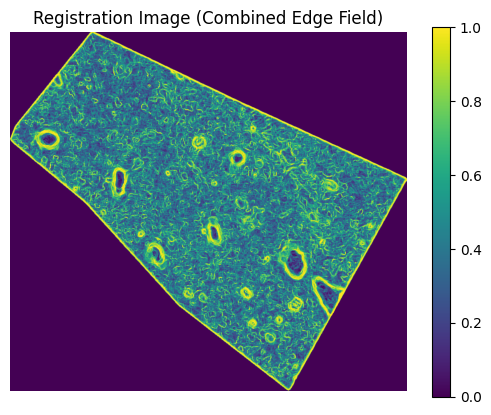

In [ ]:
####_-------GLOBALS-------#####
DENOISE_METHOD = "median"
GAUSSIAN_SIGMA_PIXELS = 5.0
MEDIAN_RADIUS_PIXELS = 5.0
STRUCTURAL_COMBINE_METHOD = "max"
REGISTRATION_FIELD = "edge"

####------HELPER FUNCTION--------------#####
def denoise_component(component: np.ndarray,
                      method: str = DENOISE_METHOD,
                      gaussian_sigma: float = GAUSSIAN_SIGMA_PIXELS,
                      median_radius: int = MEDIAN_RADIUS_PIXELS) -> np.ndarray:
    """Denoise one normalized NMF spatial component while preserving scale."""
    method = method.lower()
    if method in ("none", "off", "false"):
        denoised = component
    elif method == "gaussian":
        denoised = gaussian(component, sigma=gaussian_sigma,
                            preserve_range=True)
    elif method == "median":
        denoised = median(component, footprint=disk(median_radius))
    else:
        raise ValueError(f"Unknown NMF denoise method: {method}")
    return np.clip(np.asarray(denoised, dtype=np.float32), 0.0, 1.0)
####------HELPER FUNCTION--------------#####

#### running the full build_maldi_data() code 
def build_maldi_data(imzml_path: str,
                     n_components: int = 8,
                     mz_bin_width: float = 0.1,
                     mz_bin_min_count: int = 100,
                     min_intensity: float = 5.0,
                     pixel_size_um: float = 5.0,
                     denoise_method: str = DENOISE_METHOD,
                     gaussian_sigma: float = GAUSSIAN_SIGMA_PIXELS,
                     median_radius: int = MEDIAN_RADIUS_PIXELS,
                     structural_combine: str = STRUCTURAL_COMBINE_METHOD,
                     registration_field: str = REGISTRATION_FIELD) -> dict:
    """
    Load MSI, run NMF, and build structural fields for registration.

    Returns dict with:
      components      [K, H, W] float32, raw per-component normalized [0, 1]
      denoised_components [K, H, W] float32, denoised components normalized [0, 1]
      structural_fields dict of MALDI edge/orientation/anisotropy/vesselness
      registration_image [H, W] selected structural field for registration
      component_spectra [K, n_bins] float32 - the H matrix of NMF
      mz_axis         [n_bins] float32 - bin-center m/z values
      pixel_size_um   float - physical size of one MALDI pixel
      grid_shape      (H, W)
      n_components    K
      grid_origin     (x0, y0) - offset of MALDI grid origin in imzML coords
    """
    parser = ImzMLParser(imzml_path)
    coords_list = list(parser.coordinates)
    xs = np.array([c[0] for c in coords_list])
    ys = np.array([c[1] for c in coords_list])
    x0, y0 = int(xs.min()), int(ys.min())
    H = int(ys.max() - y0 + 1)
    W = int(xs.max() - x0 + 1)
    n_px = len(coords_list)
    print(f"[1/7] Loaded {n_px} spectra | grid {H}×{W} | {pixel_size_um} μm/pixel")

    # First pass -- collect intensity-filtered peaks for dense m/z binning.
    all_mzs = []
    all_intensities = []
    all_pixel_indices = []
    for idx in range(n_px):
        mzs, ints = parser.getspectrum(idx)
        m = ints > min_intensity
        if m.any():
            all_mzs.append(mzs[m].astype(np.float64, copy=False))
            all_intensities.append(ints[m].astype(np.float32, copy=False))
            all_pixel_indices.append(np.full(int(m.sum()), idx, dtype=np.int64))
    if not all_mzs:
        raise RuntimeError("No spectra survived intensity threshold")

    all_mzs = np.concatenate(all_mzs)
    all_intensities = np.concatenate(all_intensities)
    all_pixel_indices = np.concatenate(all_pixel_indices)
    mz_min = float(all_mzs.min())
    mz_max = float(all_mzs.max())
    print(
        f"[1/7] m/z [{mz_min:.2f}, {mz_max:.2f}] | "
        f"dense bin tolerance {mz_bin_width} Da | min_count={mz_bin_min_count}"
    )

    binned_mzs, binned_intensities, binned_pixel_indices, bin_labels = dense_mz_bins(
        all_mzs,
        all_intensities,
        all_pixel_indices,
        mz_tol=mz_bin_width,
        min_count=mz_bin_min_count,
    )
    if len(bin_labels) == 0:
        raise RuntimeError(
            "Dense m/z binning produced no bins. Try increasing --mz_bin or "
            "lowering --mz_bin_min_count."
        )

    unique_bin_labels, bin_index = np.unique(bin_labels, return_inverse=True)
    n_bins = len(unique_bin_labels)
    bin_centers = np.bincount(bin_index, weights=binned_mzs) / np.bincount(bin_index)
    print(f"[1/7] Dense m/z binning kept {len(binned_mzs):,} values in {n_bins} bins")

    # Fill the [n_pixels, n_bins] matrix.
    X = np.zeros((n_px, n_bins), dtype=np.float32)
    np.add.at(X, (binned_pixel_indices, bin_index), binned_intensities)

    # Drop empty bins (saves memory and speeds up NMF)
    nonzero = X.sum(axis=0) > 0
    X = X[:, nonzero]
    bin_centers = bin_centers[nonzero]
    print(f"[1/7] Spectral matrix: {X.shape}")

    # NMF
    print(f"[2/7] NMF with k={n_components}")
    model = NMF(n_components=n_components, init="nndsvda",
                max_iter=500, random_state=42)
    W_mat = model.fit_transform(X)
    print(f"[2/7] NMF reconstruction error: {model.reconstruction_err_:.3f}")

    # Build per-component images, normalize each to [0, 1]
    comp_imgs = np.zeros((n_components, H, W), dtype=np.float32)
    rows = np.array([int(c[1] - y0) for c in coords_list], dtype=int)
    cols = np.array([int(c[0] - x0) for c in coords_list], dtype=int)
    for k in range(n_components):
        c = W_mat[:, k]
        c = c / (c.max() + 1e-8)
        comp_imgs[k, rows, cols] = c

    print(f"[2/7] Denoising NMF components with method='{denoise_method}'")
    denoised_comp_imgs = np.zeros_like(comp_imgs, dtype=np.float32)
    for k in range(n_components):
        denoised_comp_imgs[k] = denoise_component(
            comp_imgs[k],
            method=denoise_method,
            gaussian_sigma=gaussian_sigma,
            median_radius=median_radius,
        )

    print(f"[2/7] Computing MALDI structural fields from {n_components} NMF components")
    component_fields = [
        compute_structural_fields(denoised_comp_imgs[k])
        for k in range(n_components)
    ]
    structural_fields = combine_component_structural_fields(
        component_fields, method=structural_combine)
    if registration_field not in structural_fields or registration_field == "orientation":
        raise ValueError("registration_field must be 'edge', 'anisotropy', or 'vesselness'")

    return {
        "components":        comp_imgs.astype(np.float32),
        "denoised_components": denoised_comp_imgs.astype(np.float32),
        "component_structural_fields": component_fields,
        "structural_fields": structural_fields,
        "registration_image": structural_fields[registration_field].astype(np.float32),
        "component_spectra": model.components_.astype(np.float32),
        "mz_axis":           bin_centers.astype(np.float32),
        "pixel_size_um":     float(pixel_size_um),
        "grid_shape":        (H, W),
        "n_components":      int(n_components),
        "grid_origin":       (x0, y0),
    }
imzml_path = "/home/kia/MALDI_Metabolomics/MSI_data_grant/Mass_Spec_data/20251012_old_liver_profiles.imzML"
maldi_data = build_maldi_data(imzml_path)
print(maldi_data.keys())
print(maldi_data["components"].shape) # this should be (n_components, H, W)
print(maldi_data["denoised_components"].shape) # this should also be (n_components, H, W)
print(maldi_data["structural_fields"].keys()) # this should show the keys of the structural fields dict, which are "edge", "orientation", "anisotropy", and "vesselness". Each of these is a 2D array of shape (H, W) containing the corresponding structural field for the combined components.
print(maldi_data["registration_image"].shape) # this should be (H, W) and should correspond to the structural field selected for registration, which in this case is "vesselness".
plt.imshow(maldi_data["registration_image"], cmap="viridis")
plt.colorbar()
plt.title("Registration Image (Combined Edge Field)")
plt.axis("off")
plt.show()

#### Stage 2: Prepare H&E 
Mostly simple function. It gray scales and downsamples H&E to the maldi grid resolution (smooths before downsampling), then calculates the structural descriptors on the new resized gray scaled H&E

[3/7] H&E pixel size inferred at 0.271 μm (area-matched against MALDI)
[3/7] Resizing H&E (12468, 15297) → (713, 787) (downsample 17.5×19.4)
[3/7] Computing H&E structural fields
(12468, 15297)
(713, 787)
4
dict_keys(['edge', 'orientation', 'anisotropy', 'vesselness'])
0.2708281840933358


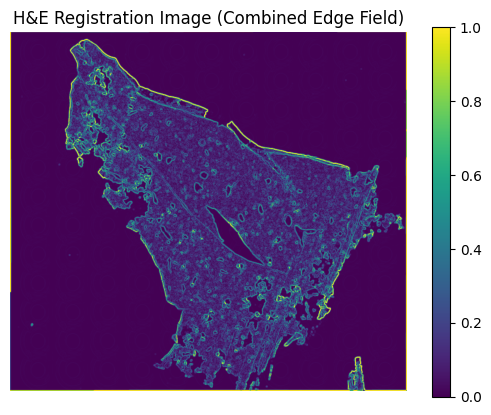

In [15]:

def prepare_he(he_path: str,
               target_shape: tuple,
               use_hematoxylin: bool = True,
               pixel_size_um: float = None,
               maldi_um_per_pixel: float = 5.0,
               registration_field: str = REGISTRATION_FIELD) -> dict:
    """
    Load H&E, optionally extract hematoxylin channel, and produce two
    versions: full resolution (preserved for cellular queries) and a
    downsampled copy on the MALDI grid (used for registration).

    Returns dict with:
      full_resolution      [H_full, W_full] float32 in [0, 1]
      registration_grid    [H, W] float32 in [0, 1] (matches MALDI grid)
      structural_fields    dict of H&E edge/orientation/anisotropy/vesselness
      registration_image   selected structural field for registration
      downsample_factor    (dy, dx) — full → registration scale per axis
      pixel_size_um        float — H&E pixel size, inferred if not given
    """
    ### ---grey scale normalization and optional hematoxylin extraction--- ###
    rgb = skio.imread(he_path)
    if rgb.ndim == 3 and rgb.shape[2] == 4:
        rgb = rgb[..., :3]

    if rgb.ndim == 3 and use_hematoxylin:
        hed = rgb2hed(rgb)
        gray_full = hed[..., 0].astype(np.float32)        # hematoxylin
    elif rgb.ndim == 3:
        gray_full = 1.0 - rgb2gray(rgb).astype(np.float32)  # invert so tissue is bright
    else:
        gray_full = rgb.astype(np.float32)
    gray_full = (gray_full - gray_full.min()) / (gray_full.max() - gray_full.min() + 1e-8)

    # Infer pixel size from area-matching assumption if not provided
    downsample_y = gray_full.shape[0] / target_shape[0]
    downsample_x = gray_full.shape[1] / target_shape[1]
    if pixel_size_um is None:
        pixel_size_um = maldi_um_per_pixel / ((downsample_y + downsample_x) / 2.0)
        print(f"[3/7] H&E pixel size inferred at {pixel_size_um:.3f} μm "
              f"(area-matched against MALDI)")
    else:
        print(f"[3/7] H&E pixel size given: {pixel_size_um:.3f} μm")

    print(f"[3/7] Resizing H&E {gray_full.shape} → {target_shape} "
          f"(downsample {downsample_y:.1f}×{downsample_x:.1f})")
    gray_reg = resize(gray_full, target_shape, anti_aliasing=True,
                      preserve_range=True).astype(np.float32)
    if gray_reg.max() > gray_reg.min():
        gray_reg = (gray_reg - gray_reg.min()) / (gray_reg.max() - gray_reg.min())

    print("[3/7] Computing H&E structural fields")
    structural_fields = compute_structural_fields(gray_reg)
    if registration_field not in structural_fields or registration_field == "orientation":
        raise ValueError("registration_field must be 'edge', 'anisotropy', or 'vesselness'")

    return {
        "full_resolution":    gray_full,
        "registration_grid":  gray_reg,
        "structural_fields":  structural_fields,
        "registration_image": structural_fields[registration_field].astype(np.float32),
        "downsample_factor":  (float(downsample_y), float(downsample_x)),
        "pixel_size_um":      float(pixel_size_um),
        "full_resolution_shape": tuple(gray_full.shape),
    }

he = prepare_he(he_path="/home/kia/MALDI_Metabolomics/high_res_MSI/D2_10x_originalExport.tif",
                target_shape=maldi_data["grid_shape"],
                use_hematoxylin=True,
                pixel_size_um=None,  # infer from area-matching
                maldi_um_per_pixel=maldi_data["pixel_size_um"],
                registration_field=REGISTRATION_FIELD)
print(he['full_resolution'].shape) # this should be the shape of the original H&E image, which is likely much larger than the MALDI grid shape.
print(he['registration_grid'].shape) # this should match the MALDI grid shape (H, W) and should be a downsampled version of the H&E image.
print(len(he['structural_fields']))
print(he['structural_fields'].keys()) # this should show the keys of the structural fields dict, which are "edge", "orientation", "anisotropy", and "vesselness". Each of these is a 2D array of shape (H, W) containing the corresponding structural field for the downsampled H&E image
print(he['pixel_size_um']) # this should show the inferred pixel size of the H&E image in microns, which is calculated based on the downsample factor and the MALDI pixel size.
plt.imshow(he['registration_image'], cmap="viridis")
plt.colorbar()
plt.title("H&E Registration Image (Combined Edge Field)")
plt.axis("off")
plt.show()

Double checking to see if my assumptions on the preprocessing of the H&E were corrected. (we do not need to combine structural descriptors for this modality)

(12468, 15297)


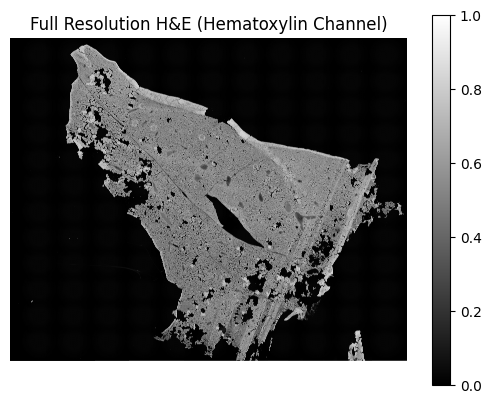

In [16]:
# checking the preprocessing of the H&E image, including the grayscale normalization and optional hematoxylin extraction. This will help us verify that the H&E image is being loaded and processed correctly before we compute the structural fields and use it for registration.
he_path="/home/kia/MALDI_Metabolomics/high_res_MSI/D2_10x_originalExport.tif"
use_hematoxylin = False
rgb = skio.imread(he_path)
if rgb.ndim == 3 and rgb.shape[2] == 4:
    rgb = rgb[..., :3]

if rgb.ndim == 3 and use_hematoxylin:
    hed = rgb2hed(rgb)
    gray_full = hed[..., 0].astype(np.float32)        # hematoxylin
elif rgb.ndim == 3:
    gray_full = 1.0 - rgb2gray(rgb).astype(np.float32)  # invert so tissue is bright
else:
    gray_full = rgb.astype(np.float32)
gray_full = (gray_full - gray_full.min()) / (gray_full.max() - gray_full.min() + 1e-8)
print(gray_full.shape) # t
plt.imshow(gray_full, cmap="gray")
plt.colorbar()
plt.title("Full Resolution H&E (Hematoxylin Channel)")
plt.axis("off")
plt.show()

#### Stage 3: Vessel Detection
##### - detect_vessels()
placeholder for function details 

In [ ]:
# globals for vessel detection
VESSEL_THRESHOLD_PERCENTILE = 94.0
VESSEL_MIN_AREA = 50
VESSEL_MAX_AREA = 5000
VESSEL_MIN_ECCENTRICITY = 0.35
VESSEL_MIN_COUNT_FOR_OBJECTIVE = 8

def detect_vessels(vesselness: np.ndarray,
                   min_area: int = VESSEL_MIN_AREA,
                   max_area: int = VESSEL_MAX_AREA,
                   threshold_percentile: float = VESSEL_THRESHOLD_PERCENTILE,
                   min_eccentricity: float = VESSEL_MIN_ECCENTRICITY) -> dict:
    """
    Detect vessel-like regions and return their centers and shape properties.

    The output coordinates are in registration-grid pixels: x is column,
    y is row. These are the same coordinates used by SimpleITK transforms.
    """
    vessel = normalize01(vesselness)

    if np.all(vessel == 0): # if the vesselness image is completely empty, return empty results without error
        empty = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])
        print("Vesselness image is empty, returning empty vessel table.")
        return {"mask": np.zeros_like(vessel, dtype=bool),
                "labels": np.zeros_like(vessel, dtype=np.int32),
                "table": empty}

    percentile_thr = np.percentile(vessel[vessel > 0], threshold_percentile) if np.any(vessel > 0) else 1.0
    try:
        otsu_thr = threshold_otsu(vessel)
        threshold = max(float(percentile_thr), float(otsu_thr))
    except ValueError:
        threshold = float(percentile_thr)

    mask = vessel >= threshold
    #mask = ndi.binary_fill_holes(mask) # looks for 0s surrounded by 1s and fills them in, which can help connect fragmented vessel regions.
    labels_img = label(mask) # measuring the connected components in the binary mask, which should correspond to individual vessel-like regions.
    props = regionprops_table(
        labels_img,
        properties=("label", "area", "centroid", "eccentricity", "orientation"),
    )
    table = pd.DataFrame(props)
    print(f"Detected {len(table)} vessel candidates before filtering by area and eccentricity.")
    if table.empty:
        table = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])
        return {"mask": mask,
                "labels": labels_img.astype(np.int32),
                "table": table}

    table = table.rename(columns={"centroid-0": "y", "centroid-1": "x"})
    table = table[
        (table["area"] >= min_area) &
        (table["area"] <= max_area) &
        (table["eccentricity"] >= min_eccentricity)
    ].copy()
    keep_labels = set(table["label"].astype(int))
    labels_img = np.where(np.isin(labels_img, list(keep_labels)), labels_img, 0)
    mask = labels_img > 0
    table = table[["x", "y", "area", "eccentricity", "orientation"]].reset_index(drop=True)
    return {"mask": mask,
            "labels": labels_img.astype(np.int32),
            "table": table}

trouble shooting outputs from detected vessel function...ran a check and only 1 vessel is detected? but the vesselness shows a lot of signal

Detected 1 vessel candidates before filtering by area and eccentricity.


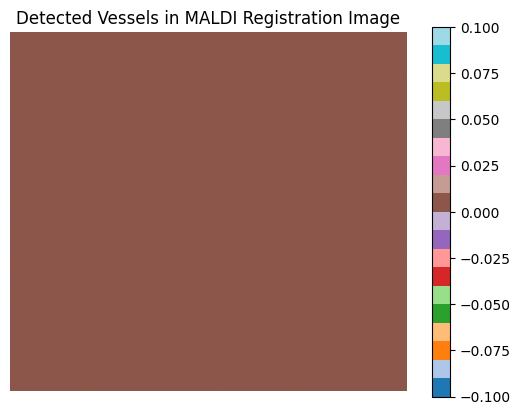

In [18]:
maldi_vessels = maldi_data["structural_fields"]["vesselness"]
vessel_results = detect_vessels(maldi_vessels)
plt.imshow(vessel_results["labels"], cmap="tab20")
plt.colorbar()
plt.title("Detected Vessels in MALDI Registration Image")
plt.axis("off")
plt.show()

This is weird because both vessel and mask variables are not seeing anything....no matter what I do about the global parameters....need to continue dissecting this function 

Detected 1422 vessel candidates before filtering by area and eccentricity.


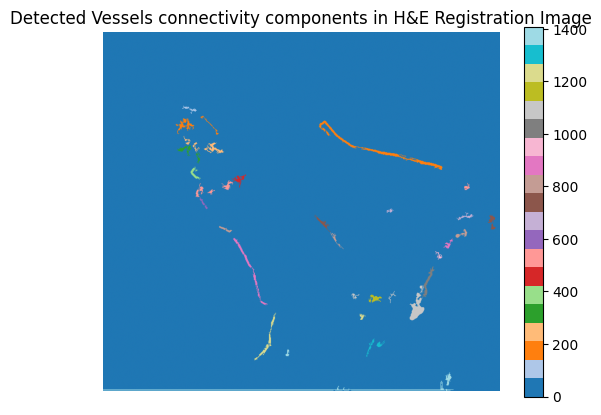

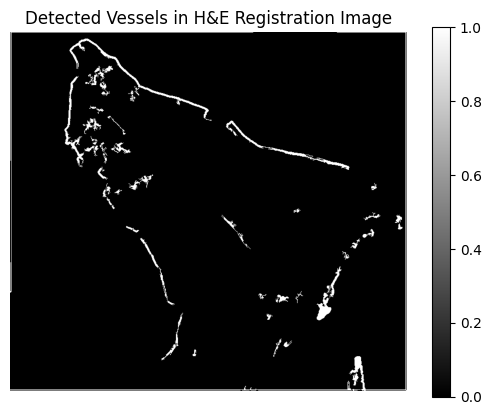

In [19]:
he_vessels = he["structural_fields"]["vesselness"]
vessel_results = detect_vessels(he_vessels)
plt.imshow(vessel_results["labels"], cmap="tab20")
plt.colorbar()
plt.title("Detected Vessels connectivity components in H&E Registration Image")
plt.axis("off")
plt.show()

plt.imshow(vessel_results["mask"], cmap="grey")
plt.colorbar()
plt.title("Detected Vessels in H&E Registration Image")
plt.axis("off")
plt.show()

It looks like the H&E vessel detection is working better.

amount of nonzero vesselness pixels: 284856
total maldi pixels: 561131
vessel datastructure shape: (713, 787)


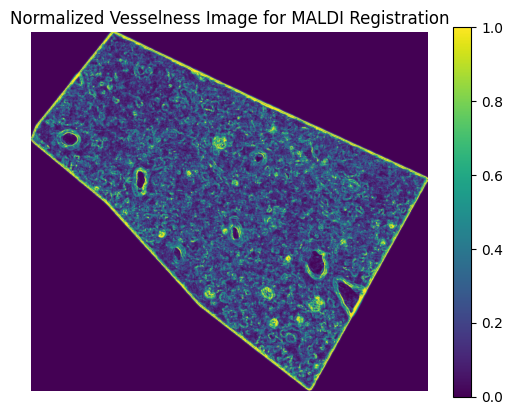

In [20]:
# globals for vessel detection
VESSEL_THRESHOLD_PERCENTILE = 90.0
VESSEL_MIN_AREA = 50
VESSEL_MAX_AREA = 5000
VESSEL_MIN_ECCENTRICITY = 0.35
VESSEL_MIN_COUNT_FOR_OBJECTIVE = 8


# for now we are going to just troubleshoot on the MALDI vesselness image, since the H&E one is looking pretty good. 
# We want to check the vesselness image itself, the thresholding step, and the connected component labeling step to see 
# where things might be going wrong.
vesselness = maldi_data["structural_fields"]["vesselness"]
threshold_percentile = VESSEL_THRESHOLD_PERCENTILE
min_area = VESSEL_MIN_AREA
max_area = VESSEL_MAX_AREA
min_eccentricity = VESSEL_MIN_ECCENTRICITY

# running first part of the detect_vessels function to check the vesselness image and the thresholding step.
vessel = normalize01(vesselness)

if np.all(vessel == 0): # if the vesselness image is completely empty, return empty results without error
    empty = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])
    print("Vesselness image is empty, returning empty vessel table.")

print(f'amount of nonzero vesselness pixels: {np.count_nonzero(vessel)}')
print(f'total maldi pixels: {vessel.size}')
print(f'vessel datastructure shape: {vessel.shape}')
plt.imshow(vessel, cmap="viridis")
plt.colorbar()
plt.title("Normalized Vesselness Image for MALDI Registration")
plt.axis("off")
plt.show()

Ok so just looking at the vessel field of the maldi we see ~285K spots with intensity > 0.....which is weird because we only have 269K spots that are within the tissue....This is due to the tissue border and blurring due to the sigma param....problem solved 

In [21]:
percentile_thr = np.percentile(vessel[vessel > 0], threshold_percentile) if np.any(vessel > 0) else 1.0
print(f"Vesselness threshold at {threshold_percentile} percentile: {percentile_thr:.4f}")
try:
    otsu_thr = threshold_otsu(vessel)
    threshold = max(float(percentile_thr), float(otsu_thr))
except ValueError:
    threshold = float(percentile_thr)

# plot the vesselness image and the threshold to visually inspect them
print(f"Vesselness threshold calculated: {threshold:.4f}")
print(f"Vesselness threshold: {threshold:.4f} (percentile {threshold_percentile}%)")
print(f"number of vesselness pixels above threshold: {(vessel >= threshold).sum()} out of {np.count_nonzero(vessel)} total nonzero pixels")

Vesselness threshold at 90.0 percentile: 0.5531
Vesselness threshold calculated: 0.5531
Vesselness threshold: 0.5531 (percentile 90.0%)
number of vesselness pixels above threshold: 28486 out of 284856 total nonzero pixels


Number of pixels in vessel mask after thresholding and hole filling: 28486 out of 561131 total pixels


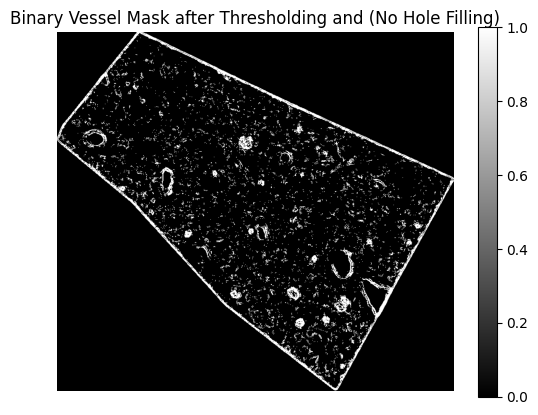

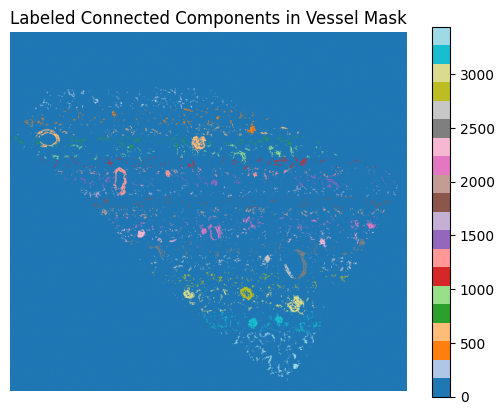

In [22]:
mask = vessel >= threshold # threshold = float()
#mask = ndi.binary_fill_holes(mask) # looks for 0s surrounded by 1s and fills them in, which can help connect fragmented vessel regions.
print(f"Number of pixels in vessel mask after thresholding and hole filling: {mask.sum()} out of {vessel.size} total pixels")
plt.imshow(mask, cmap="gray")
plt.colorbar()
plt.title("Binary Vessel Mask after Thresholding and (No Hole Filling)")
plt.axis("off")
plt.show()
labels_img = label(mask) # measuring the connected components in the binary mask, which should correspond to individual vessel-like regions.
plt.imshow(labels_img, cmap="tab20")
plt.colorbar()
plt.title("Labeled Connected Components in Vessel Mask")
plt.axis("off")
plt.show()

Ok the bug was in the ndi.binary_fill_holes() this was filling the entire maldi region and treating it as one big pixel

In [23]:
props = regionprops_table(
    labels_img,
    properties=("label", "area", "centroid", "eccentricity", "orientation"),
)
table = pd.DataFrame(props)
print(f"Detected {len(table)} vessel candidates before filtering by area and eccentricity.")
if table.empty:
    table = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])


table = table.rename(columns={"centroid-0": "y", "centroid-1": "x"})
table = table[
    (table["area"] >= min_area) &
    (table["area"] <= max_area) &
    (table["eccentricity"] >= min_eccentricity)
].copy()
keep_labels = set(table["label"].astype(int))
print
labels_img = np.where(np.isin(labels_img, list(keep_labels)), labels_img, 0)
mask = labels_img > 0
table = table[["x", "y", "area", "eccentricity", "orientation"]].reset_index(drop=True)

Detected 3439 vessel candidates before filtering by area and eccentricity.


In [24]:
# used to create dataframe of region properties for each connected component in the vessel mask, which includes 
# the label, area, centroid coordinates, eccentricity, and orientation of each detected vessel candidate before filtering. 
# This will help us understand the characteristics of the detected regions and how many candidates we have before applying the area 
# and eccentricity filters.
props 

{'label': array([   1,    2,    3, ..., 3437, 3438, 3439], shape=(3439,)),
 'area': array([1.1047e+04, 1.0000e+00, 3.0000e+00, ..., 7.0000e+00, 2.0000e+00,
        1.0000e+00], shape=(3439,)),
 'centroid-0': array([336.81922694,  13.        ,  19.        , ..., 681.42857143,
        688.5       , 691.        ], shape=(3439,)),
 'centroid-1': array([405.14166742, 165.        , 158.66666667, ..., 532.42857143,
        549.        , 550.        ], shape=(3439,)),
 'eccentricity': array([0.78701552, 0.        , 0.97372313, ..., 0.89328335, 1.        ,
        0.        ], shape=(3439,)),
 'orientation': array([ 0.91445987, -0.78539816,  0.49139686, ...,  0.58478376,
         0.        , -0.78539816], shape=(3439,))}

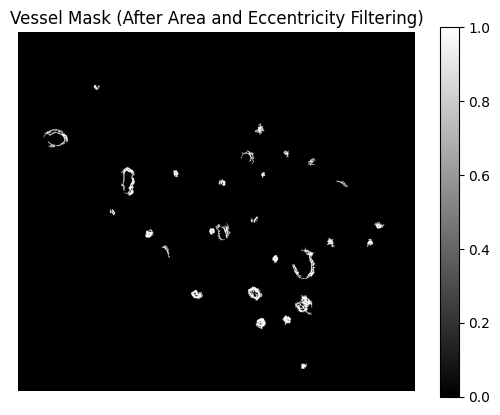

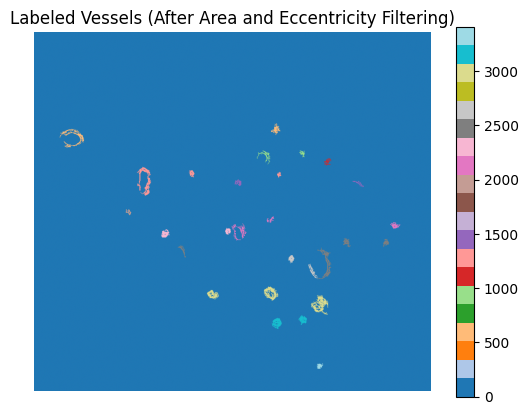

In [25]:
plt.imshow(mask, cmap="grey")
plt.colorbar()
plt.title("Vessel Mask (After Area and Eccentricity Filtering)")
plt.axis("off")
plt.show()

plt.imshow(labels_img, cmap="tab20")
plt.colorbar()
plt.title("Labeled Vessels (After Area and Eccentricity Filtering)")
plt.axis("off")
plt.show()

Ok now we know what the vessel mask and connectivity mask looks like at the end of the function detect vessels....time to see how it performs on both MALDI and H&E samples...Below I made a new_detect_vessels function by just getting rid of ndi.fill_holes and min/max area filtering plus eccentricity filtering 

In [26]:
def new_detect_vessels(vesselness: np.ndarray,
                   threshold_percentile: float = VESSEL_THRESHOLD_PERCENTILE,
                   min_area: float = VESSEL_MIN_AREA,
                   max_area: float = VESSEL_MAX_AREA,
                   min_eccentricity: float = VESSEL_MIN_ECCENTRICITY) -> dict:
    """
    Detect vessel-like regions and return their centers and shape properties.

    The output coordinates are in registration-grid pixels: x is column,
    y is row. These are the same coordinates used by SimpleITK transforms.
    """
    vessel = normalize01(vesselness)

    if np.all(vessel == 0): # if the vesselness image is completely empty, return empty results without error
        empty = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])
        print("Vesselness image is empty, returning empty vessel table.")
        return {"mask": np.zeros_like(vessel, dtype=bool),
                "labels": np.zeros_like(vessel, dtype=np.int32),
                "table": empty}

    percentile_thr = np.percentile(vessel[vessel > 0], threshold_percentile) if np.any(vessel > 0) else 1.0
    try:
        otsu_thr = threshold_otsu(vessel)
        threshold = max(float(percentile_thr), float(otsu_thr))
    except ValueError:
        threshold = float(percentile_thr)

    mask = vessel >= threshold
    #mask = ndi.binary_fill_holes(mask) # looks for 0s surrounded by 1s and fills them in, which can help connect fragmented vessel regions.
    labels_img = label(mask) # measuring the connected components in the binary mask, which should correspond to individual vessel-like regions.
    props = regionprops_table(
        labels_img,
        properties=("label", "area", "centroid", "eccentricity", "orientation"),
    )
    table = pd.DataFrame(props)
    print(f"Detected {len(table)} vessel candidates before filtering by area and eccentricity.")
    if table.empty:
        table = pd.DataFrame(columns=["x", "y", "area", "eccentricity", "orientation"])
        return {"mask": mask,
                "labels": labels_img.astype(np.int32),
                "table": table}

    table = table.rename(columns={"centroid-0": "y", "centroid-1": "x"})
    table = table[
        (table["area"] >= min_area) &
        (table["area"] <= max_area) &
        (table["eccentricity"] >= min_eccentricity)
    ].copy()
    keep_labels = set(table["label"].astype(int))
    labels_img = np.where(np.isin(labels_img, list(keep_labels)), labels_img, 0)
    mask = labels_img > 0
    table = table[["x", "y", "area", "eccentricity", "orientation"]].reset_index(drop=True)
    return {"mask": mask,
            "labels": labels_img.astype(np.int32),
            "table": table}

Detected 1426 vessel candidates before filtering by area and eccentricity.


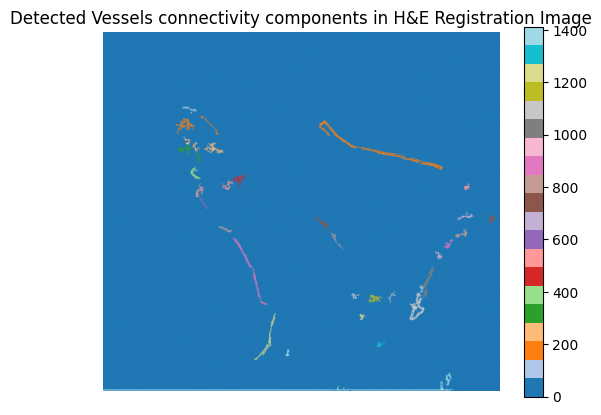

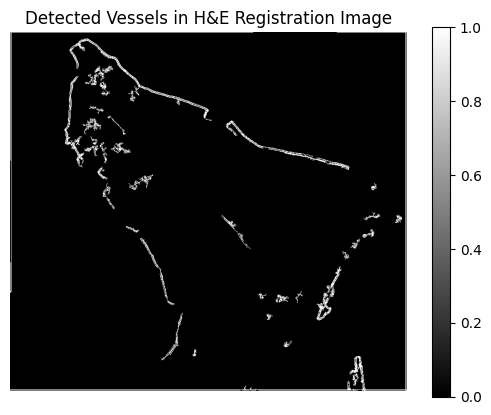

Detected 3439 vessel candidates before filtering by area and eccentricity.


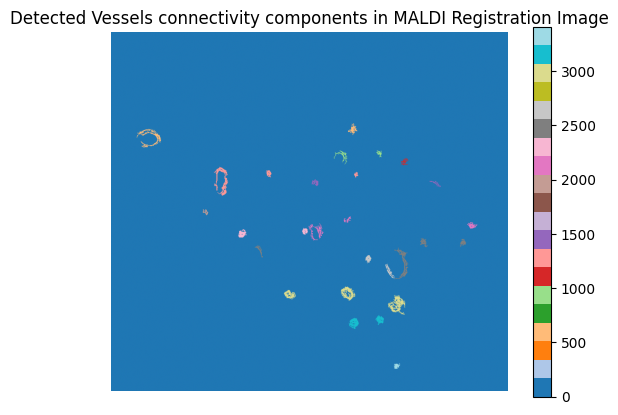

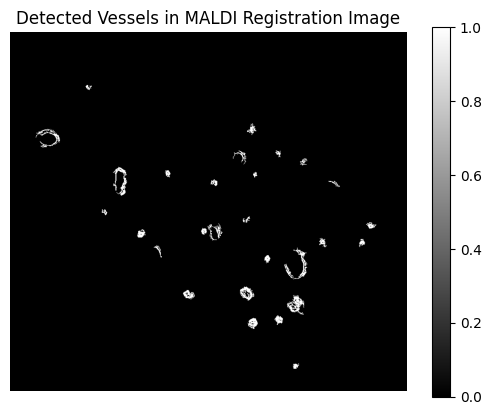

In [27]:
he_vessels = he["structural_fields"]["vesselness"]
he_vessel_results = new_detect_vessels(he_vessels)
plt.imshow(he_vessel_results["labels"], cmap="tab20")
plt.colorbar()
plt.title("Detected Vessels connectivity components in H&E Registration Image")
plt.axis("off")
plt.show()

plt.imshow(he_vessel_results["mask"], cmap="grey")
plt.colorbar()
plt.title("Detected Vessels in H&E Registration Image")
plt.axis("off")
plt.show()

maldi_vessels = maldi_data["structural_fields"]["vesselness"]
maldi_vessel_results = new_detect_vessels(maldi_vessels)
plt.imshow(maldi_vessel_results["labels"], cmap="tab20")
plt.colorbar()
plt.title("Detected Vessels connectivity components in MALDI Registration Image")
plt.axis("off")
plt.show()

plt.imshow(maldi_vessel_results["mask"], cmap="grey")
plt.colorbar()
plt.title("Detected Vessels in MALDI Registration Image")
plt.axis("off")
plt.show()

Ok bug in the vessel mask has been fixed :).....but I think that we can also get rid of the min/max area filtering and eccentricity filtering. It depends on how we are aligning but for now I will get rid of it because it gets rid of the border of the maldi tissue section  

#### Stage 4: build_tissue_mask()
Pretty simple function it takes the weighted sum of the three structural features and only looks at the positive components of the weighted_sum vector. Then we look at the top pixels that meet the tissue mask theshold (i.e if tissue mask threshold is 85 we filter for the top 85 percent in ) and then we also filter out objects that are below a certain pixel size. For example, a boolean mask if we have less than 64 connected componets than we filter those objects out. 

In [28]:
TISSUE_MASK_THRESHOLD_PERCENTILE = 55.0
TISSUE_MASK_MIN_SIZE = 64
def build_tissue_mask(fields: dict,
                      threshold_percentile: float = TISSUE_MASK_THRESHOLD_PERCENTILE,
                      min_size: int = TISSUE_MASK_MIN_SIZE) -> np.ndarray:
    """
    Build a tissue-support mask from structural evidence, not raw intensity.

    This mask limits structural-difference and tissue-overlap scoring to the
    tissue support, so background zeros do not reward bad transforms.
    """
    support = (
        0.70 * normalize01(fields["edge"]) +
        0.20 * normalize01(fields["anisotropy"]) +
        0.10 * normalize01(fields["vesselness"])
    )
    positive = support[support > 0]
    if positive.size == 0:
        return np.ones_like(support, dtype=bool)

    threshold = np.percentile(positive, threshold_percentile)
    mask = support >= threshold
    #mask = ndi.binary_fill_holes(mask)
    mask = ndi.binary_closing(mask, structure=np.ones((3, 3), dtype=bool))
    mask = remove_small_objects(mask.astype(bool), min_size=min_size)
    if not np.any(mask):
        return np.ones_like(support, dtype=bool)
    return mask.astype(bool)

Going to look at the maldi tissue mask first....but to be honest the H&E on the full run looks worse right now 

/tmp/ipykernel_150528/1303313163.py:25: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=min_size)


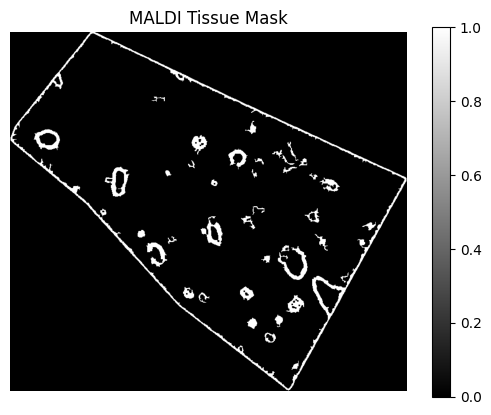

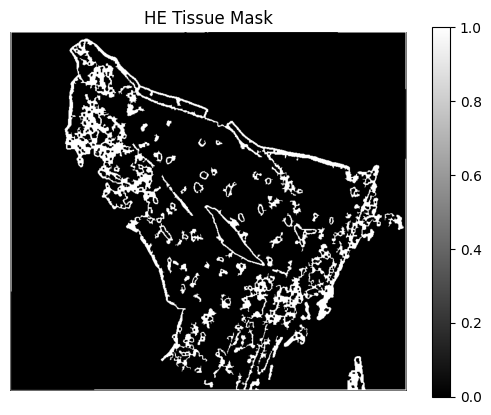

In [29]:
# function call  + globals for tissue mask building
TISSUE_MASK_THRESHOLD_PERCENTILE = 90.0
TISSUE_MASK_MIN_SIZE = 64

maldi_tissue_mask = build_tissue_mask(maldi_data["structural_fields"],
                                     threshold_percentile=TISSUE_MASK_THRESHOLD_PERCENTILE,
                                     min_size=TISSUE_MASK_MIN_SIZE)
plt.imshow(maldi_tissue_mask, cmap="gray")
plt.colorbar()
plt.title("MALDI Tissue Mask")
plt.axis("off")
plt.show()

he_tissue_mask = build_tissue_mask(he["structural_fields"],
                                     threshold_percentile=TISSUE_MASK_THRESHOLD_PERCENTILE,
                                     min_size=TISSUE_MASK_MIN_SIZE)
plt.imshow(he_tissue_mask, cmap="gray")
plt.colorbar()
plt.title("HE Tissue Mask")
plt.axis("off")
plt.show()

All in all the biggest bug in the code is the ndi.binary_fill_holes() its really killing us in this script 

#### Stage 5: optimize_biological_transform() ... the big one how everything comes together 
place holder

##### * 5a: np_to_stk()
helper functions that literally just change numpy arrays into simpleitk arrays. 

Here’s what a SimpleITK image carries:

pixel spacing (e.g., 0.5 µm per pixel)

origin (physical coordinate of pixel (0,0))

direction matrix (orientation in physical space)

data type

metadata tags (DICOM, TIFF, etc.)

In [30]:
def np_to_sitk(arr: np.ndarray) -> sitk.Image:
    return sitk.GetImageFromArray(arr.astype(np.float32))

maldi_reg_image_sitk = np_to_sitk(maldi_data["registration_image"])
he_reg_image_sitk = np_to_sitk(he["registration_image"])
print(f"MALDI registration image size: {maldi_reg_image_sitk.GetSize()}")
print(f"H&E registration image size: {he_reg_image_sitk.GetSize()}")

MALDI registration image size: (787, 713)
H&E registration image size: (787, 713)


looks like the optimize_biological_transform is a function that contains multiple functions within it, most interestingly biological_objective_components()?  So we will first explort this function. 

#### * 5b: biological_objective_components()
place holder for what it is doing

Helper functions used in the pipeline

In [31]:
# helper functions for converting between numpy arrays and SimpleITK images, which are needed for the registration process. 
# The np_to_sitk function converts a numpy array to a SimpleITK image, 
# while the sitk_to_np function converts a SimpleITK image back to a numpy array. 
# The warp_to_fixed function applies a given transform to a moving image and resamples it onto the fixed image space, 
# returning the result as a numpy array. The warp_mask_to_fixed function does the same but uses nearest neighbor interpolation 
# to preserve the binary nature of masks.
def np_to_sitk(arr: np.ndarray) -> sitk.Image:
    return sitk.GetImageFromArray(arr.astype(np.float32))

def mask_to_sitk(mask: np.ndarray) -> sitk.Image:
    return sitk.GetImageFromArray(mask.astype(np.uint8))

def sitk_to_np(img: sitk.Image) -> np.ndarray:
    return sitk.GetArrayFromImage(img)

def warp_to_fixed(moving: sitk.Image, fixed: sitk.Image,
                  tx: sitk.Transform) -> np.ndarray:
    return sitk_to_np(sitk.Resample(moving, fixed, tx, sitk.sitkLinear, 0.0))

def warp_mask_to_fixed(mask: np.ndarray, fixed: sitk.Image,
                       tx: sitk.Transform) -> np.ndarray:
    moving = sitk.GetImageFromArray(mask.astype(np.uint8))
    warped = sitk.Resample(moving, fixed, tx, sitk.sitkNearestNeighbor, 0) # samples from the moving image and maps it to the fixed image space using the provided transform. The sitk.sitkNearestNeighbor interpolation method is used to ensure that the output values are either 0 or 1, preserving the binary nature of the mask.
    return sitk_to_np(warped).astype(bool)

def euler_transform_from_params(params: np.ndarray,
                                fixed_shape: tuple) -> sitk.Euler2DTransform:
    """
    Build a fixed->moving Euler transform from [angle_deg, tx_px, ty_px].

    Scale is fixed at 1.0 and no shear is allowed. This keeps optimization in
    the biologically plausible regime requested for local tissue geometry.
    """
    angle_deg, tx, ty = [float(v) for v in params]
    h, w = fixed_shape # we are using the fixed image because that is where we would like the center of the rotation to be. 
    transform = sitk.Euler2DTransform()
    transform.SetCenter(((w - 1) / 2.0, (h - 1) / 2.0))
    transform.SetAngle(np.deg2rad(angle_deg))
    transform.SetTranslation((tx, ty))
    return transform



In [32]:
MAX_TRANSLATION_PIXELS = 30.0
MAX_ROTATION_DEGREES = 10.0
MASK_DISTANCE_SCALE_PIXELS = 10.0
BIOLOGY_WEIGHT_STRUCTURAL = 1.0
BIOLOGY_WEIGHT_TISSUE_OVERLAP = 1.5
BIOLOGY_WEIGHT_TRANSFORM_SIZE = 0.35
def biological_objective_components(params: np.ndarray,
                                    fixed_image: np.ndarray,
                                    fixed_mask: np.ndarray,
                                    moving_mask: np.ndarray,
                                    fixed_sitk: sitk.Image,
                                    moving_sitk: sitk.Image) -> tuple[float, dict, sitk.Transform]:
    """
    Direct structural/biological registration objective.

    Objective terms:
      vessel_chamfer      bidirectional vessel displacement in pixels
      structural_diff     mean |warped MALDI - H&E| within tissue overlap
      lost_overlap        1 - intersection/union of structural tissue masks
      transform_size      normalized rotation/translation magnitude
    """
    # Euler transform is really only useful when you are at the same scale 
    transform = euler_transform_from_params(params, fixed_image.shape) # find some rigid transformation that is centered around H&E center
    warped_moving = warp_to_fixed(moving_sitk, fixed_sitk, transform)
    warped_mask = warp_mask_to_fixed(moving_mask, fixed_sitk, transform)

    overlap = fixed_mask & warped_mask
    union = fixed_mask | warped_mask
    if np.any(overlap):
        structural_diff = float(np.mean(np.abs(
            normalize01(warped_moving)[overlap] - normalize01(fixed_image)[overlap]
        )))
    else:
        structural_diff = 1.0

    if np.any(union):
        tissue_overlap = float(np.sum(overlap) / np.sum(union))
    else:
        tissue_overlap = 0.0
    lost_overlap = 1.0 - tissue_overlap

    angle_deg, tx, ty = [float(v) for v in params]
    transform_size = np.sqrt(
        (angle_deg / MAX_ROTATION_DEGREES) ** 2 +
        (tx / MAX_TRANSLATION_PIXELS) ** 2 +
        (ty / MAX_TRANSLATION_PIXELS) ** 2
    )

    score = (
        BIOLOGY_WEIGHT_STRUCTURAL * structural_diff +
        BIOLOGY_WEIGHT_TISSUE_OVERLAP * lost_overlap +
        BIOLOGY_WEIGHT_TRANSFORM_SIZE * transform_size
    )
    components = {
        "score": float(score),
        "angle_deg": angle_deg,
        "tx": tx,
        "ty": ty,
        "structural_diff": structural_diff,
        "tissue_overlap": tissue_overlap,
        "lost_overlap": lost_overlap,
        "transform_size": float(transform_size),
    }
    return float(score), components, transform

In [33]:
MAX_TRANSLATION_PIXELS = 30.0
MAX_ROTATION_DEGREES = 10.0
BIOLOGY_OPT_MAXITER = 35
BIOLOGY_OPT_POPSIZE = 8
def optimize_biological_transform(fixed_image: np.ndarray,
                                  moving_image: np.ndarray,
                                  fixed_mask: np.ndarray,
                                  moving_mask: np.ndarray,
                                  maldi_vessels: pd.DataFrame,
                                  he_vessels: pd.DataFrame,
                                  fixed_sitk: sitk.Image,
                                  moving_sitk: sitk.Image) -> tuple[sitk.Transform, pd.DataFrame, dict]:
    """
    Optimize the direct biological objective over a bounded rigid transform.

    Search space:
      angle_deg in [-MAX_ROTATION_DEGREES, MAX_ROTATION_DEGREES]
      tx, ty    in [-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS]
    """
    bounds = [
        (-MAX_ROTATION_DEGREES, MAX_ROTATION_DEGREES),
        (-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS),
        (-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS),
    ]
    trace = []
    vessel_cache = None
    if not maldi_vessels.empty and not he_vessels.empty:
        maldi_xy = maldi_vessels[["x", "y"]].to_numpy(dtype=np.float64)
        he_xy = he_vessels[["x", "y"]].to_numpy(dtype=np.float64)
        vessel_cache = {
            "maldi_xy": maldi_xy,
            "he_xy": he_xy,
            "maldi_nn": NearestNeighbors(n_neighbors=1).fit(maldi_xy),
            "he_nn": NearestNeighbors(n_neighbors=1).fit(he_xy),
        }

    def evaluate(params, stage):
        score, components, _ = biological_objective_components(
            np.asarray(params, dtype=float),
            fixed_image,
            fixed_mask,
            moving_mask,
            fixed_sitk,
            moving_sitk
        )
        components["stage"] = stage
        trace.append(components)
        return score

    identity_params = np.array([0.0, 0.0, 0.0], dtype=float)
    identity_score = evaluate(identity_params, "identity")
    print(f"[4/7] Identity biological objective = {identity_score:.4f}")

    print("[4/7] Optimizing direct biological objective: vessel + structure + overlap")
    result = optimize.differential_evolution(
        lambda p: evaluate(p, "global"),
        bounds=bounds,
        maxiter=BIOLOGY_OPT_MAXITER,
        popsize=BIOLOGY_OPT_POPSIZE,
        tol=0.01,
        polish=False,
        seed=42,
        workers=1,
        updating="immediate",
    )
    local = optimize.minimize(
        lambda p: evaluate(p, "local"),
        x0=result.x,
        method="Powell",
        bounds=bounds,
        options={"maxiter": 80, "xtol": 1e-3, "ftol": 1e-4},
    )

    candidates = [
        ("identity", identity_params, identity_score),
        ("global", result.x, float(result.fun)),
        ("local", local.x, float(local.fun)),
    ]
    best_name, best_params, _ = min(candidates, key=lambda item: item[2])
    best_score, best_components, best_transform = biological_objective_components(
        best_params,
        fixed_image,
        fixed_mask,
        moving_mask,
        fixed_sitk,
        moving_sitk
    )
    best_components["selected_stage"] = best_name
    best_components["score"] = best_score
    print(
        f"[4/7] Selected biological optimum from {best_name}: "
        f"struct={best_components['structural_diff']:.3f}, "
        f"overlap={best_components['tissue_overlap']:.3f}, "
        f"angle={best_components['angle_deg']:.3f}, "
        f"tx={best_components['tx']:.3f}, ty={best_components['ty']:.3f}"
    )
    return best_transform, pd.DataFrame(trace), best_components

In [34]:
maldi_vessel_results

{'mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(713, 787)),
 'labels': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(713, 787), dtype=int32),
 'table':              x           y   area  eccentricity  orientation
 0   154.964912  111.017544   57.0      0.657076     1.335866
 1   479.164384  194.452055  146.0      0.665220    -0.352017
 2    68.588785  198.990654  107.0      0.973866    -1.380770
 3    81.648649  214.038610  259.0      0.702039    -1.159435
 4   531.696970  241.924242   66.0      0.76

In [35]:
# going through the stack as I understand it, we are setting up the optimization of the biological objective function, 
# which includes terms for vessel alignment, structural similarity, and tissue overlap. We define the search space for the optimization 
# as a bounded region around the identity transform, with limits on rotation and translation. We also prepare a cache of vessel coordinates 
# and nearest neighbor models to speed up the vessel chamfer distance calculations during optimization. The evaluate function computes the 
# biological objective components for a given set of transform parameters and records the results in a trace for later analysis. 
# We first evaluate the identity transform to get a baseline score, then run a global optimization using differential evolution followed by a 
# local refinement using Powell's method. Finally, we select the best result from the identity, global, and local candidates and 
# return the corresponding transform and detailed component scores.
bounds = [
    (-MAX_ROTATION_DEGREES, MAX_ROTATION_DEGREES),
    (-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS),
    (-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS),
]
maldi_vessels = maldi_vessel_results["table"]
he_vessels = he_vessel_results["table"]
trace = []
vessel_cache = None
if not maldi_vessels.empty and not he_vessels.empty:
    maldi_xy = maldi_vessels[["x", "y"]].to_numpy(dtype=np.float64)
    he_xy = he_vessels[["x", "y"]].to_numpy(dtype=np.float64)
    vessel_cache = {
        "maldi_xy": maldi_xy,
        "he_xy": he_xy,
        "maldi_nn": NearestNeighbors(n_neighbors=1).fit(maldi_xy),
        "he_nn": NearestNeighbors(n_neighbors=1).fit(he_xy),
    }
print(trace)
print(vessel_cache.keys())
print(vessel_cache["maldi_xy"].shape)
print(vessel_cache["he_xy"].shape)
print(vessel_cache["maldi_nn"]) # these are just nearest neighbor models fitted on the vessel coordinates
print(vessel_cache["he_nn"]) # which will be used to compute the vessel chamfer distance during optimization.

[]
dict_keys(['maldi_xy', 'he_xy', 'maldi_nn', 'he_nn'])
(31, 2)
(47, 2)
NearestNeighbors(n_neighbors=1)
NearestNeighbors(n_neighbors=1)


Now I will look into what the biological objective function is about 

Want to see how the function performs now after getting rid of the vessel chamfer distance in the pipeline 

In [36]:
import sys
from pathlib import Path

# Adjust this to point to your project root
project_root = Path("/home/kia/MALDI_Metabolomics")
sys.path.append(str(project_root))

from scripts.preprocessed_structuralmap import (
    save_vessel_overlay,
    save_difference,
    save_structural_fields,
    save_component_denoising_qc,
    save_correspondence_csv,
    save_image,
    compute_correspondence_table,
    save_overlay,
    vessel_displacement_stats,
    save_vessel_displacement_qc,
)

IMZML_PATH = "/home/kia/MALDI_Metabolomics/MSI_data_grant/Mass_Spec_data/20251012_old_liver.imzML"     
HE_PATH = "/home/kia/MALDI_Metabolomics/high_res_MSI/D2_10x_originalExport_cropped.tif"
N_COMPONENTS = 10
BIN_WIDTH = 0.042
PIXEL_SIZE_UM = 5.0
DENOISE_METHOD = "gaussian"
DENOISE_SIGMA = 1.0
MEDIAN_RADIUS = 1
STRUCTURAL_COMBINE = "max"
REGISTRATION_FIELD = "edge"
BIN_MIN_COUNT = 50
def main():
    # output directory for all results
    out = Path('/home/kia/MALDI_Metabolomics/mutual_inf_reg')
# 1+2. MALDI data
    maldi = build_maldi_data(IMZML_PATH,
                              n_components=N_COMPONENTS,
                              mz_bin_width=BIN_WIDTH,
                              mz_bin_min_count=BIN_MIN_COUNT,
                              pixel_size_um=PIXEL_SIZE_UM,
                              denoise_method=DENOISE_METHOD,
                              gaussian_sigma=DENOISE_SIGMA,
                              median_radius=MEDIAN_RADIUS,
                              structural_combine=STRUCTURAL_COMBINE,
                              registration_field=REGISTRATION_FIELD)
    save_component_denoising_qc(
        maldi["components"],
        maldi["denoised_components"],
        out / "nmf_component_denoising.png",
    )
    save_structural_fields(
        maldi["structural_fields"],
        out / "maldi_structural_fields.png",
        "MALDI structural fields from NMF components",
    )

    # 3. H&E
    he = prepare_he(HE_PATH, 
                    maldi["grid_shape"],
                     use_hematoxylin=False,
                     pixel_size_um=None,
                     maldi_um_per_pixel=PIXEL_SIZE_UM,
                     registration_field=REGISTRATION_FIELD)
    save_image(he["registration_grid"], out / "he_at_registration_grid.png",
               cmap="gray", title="H&E at MALDI grid")
    save_structural_fields(
        he["structural_fields"],
        out / "he_structural_fields.png",
        "H&E hematoxylin structural fields",
    )

    # Vessel detection and pre-registration biological QC.
    maldi_vessels = new_detect_vessels(maldi["structural_fields"]["vesselness"])
    he_vessels = new_detect_vessels(he["structural_fields"]["vesselness"])
    maldi_vessels["table"].to_csv(out / "maldi_vessels.csv", index=False)
    he_vessels["table"].to_csv(out / "he_vessels.csv", index=False)
    save_vessel_overlay(
        he["structural_fields"]["edge"],
        he_vessels,
        maldi_vessels,
        out / "vessel_overlay_pre.png",
        "Pre-registration vessel centers and contours",
    )
    save_difference(maldi["registration_image"], he["registration_image"],
                     out / "structural_difference_pre.png",
                     title="Pre-registration structural-field difference")
    # ------------------------------------------------------------------
    # PRE-REGISTRATION COORDINATE EXPORT
    # Use identity transform but preserve EXACT registration geometry
    # ------------------------------------------------------------------

    print("[4/7] Exporting pre-registration coordinate map")

    identity_tx = sitk.Euler2DTransform()
    identity_tx.SetCenter((
        (maldi["grid_shape"][1] - 1) / 2.0,
        (maldi["grid_shape"][0] - 1) / 2.0
    ))
    identity_tx.SetAngle(0.0)
    identity_tx.SetTranslation((0.0, 0.0))

    corr_table, corr_cols = compute_correspondence_table(
        maldi,
        he,
        identity_tx,
        IMZML_PATH,
    )

    save_correspondence_csv(
        corr_table,
        corr_cols,
        out / "pre_registration_coordinate_map.csv"
    )

    # 4. Direct biological optimization. No MI, no shear, no scale changes:
    # optimize only rotation + translation for local tissue geometry.
    fixed  = np_to_sitk(he["registration_image"])
    moving = np_to_sitk(maldi["registration_image"])
    he_tissue_mask = build_tissue_mask(he["structural_fields"])
    maldi_tissue_mask = build_tissue_mask(maldi["structural_fields"])
    save_image(maldi_tissue_mask.astype(np.float32), out / "maldi_tissue_mask.png",
               cmap="gray", title="MALDI structural tissue mask")
    save_image(he_tissue_mask.astype(np.float32), out / "he_tissue_mask.png",
               cmap="gray", title="H&E structural tissue mask")

    final_tx, objective_trace, objective_stats = optimize_biological_transform(
        fixed_image=he["registration_image"],
        moving_image=maldi["registration_image"],
        fixed_mask=he_tissue_mask,
        moving_mask=maldi_tissue_mask,
        maldi_vessels=maldi_vessels["table"],
        he_vessels=he_vessels["table"],
        fixed_sitk=fixed,
        moving_sitk=moving,
    )
    objective_trace.to_csv(out / "biological_objective_trace.csv", index=False)
    pd.DataFrame([objective_stats]).to_csv(out / "biological_objective_summary.csv", index=False)
    with open(out / "selected_transform.txt", "w", encoding="utf-8") as f:
        f.write("selected_candidate: direct_biological_objective\n")
        f.write("reason: optimized vessel Chamfer + structural difference + tissue overlap directly\n")
        for key, value in objective_stats.items():
            f.write(f"{key}: {value}\n")

    # 6. Diagnostic visualizations
    warped_structural = warp_to_fixed(moving, fixed, final_tx)
    save_overlay(warped_structural, he["registration_image"],
                  out / "registered_overlay.png")
    save_difference(warped_structural, he["registration_image"],
                     out / "structural_difference_post.png",
                     title="Post-registration structural-field difference")

    displacement_df, displacement_stats = vessel_displacement_stats(
        maldi_vessels["table"],
        he_vessels["table"],
        final_tx,
        he["registration_image"].shape,
    )
    displacement_stats.update({
        "structural_diff": objective_stats["structural_diff"],
        "tissue_overlap": objective_stats["tissue_overlap"],
        "lost_overlap": objective_stats["lost_overlap"],
        "objective_score": objective_stats["score"],
        "angle_deg": objective_stats["angle_deg"],
        "tx": objective_stats["tx"],
        "ty": objective_stats["ty"],
    })
    displacement_df.to_csv(out / "vessel_displacements.csv", index=False)
    post_points = displacement_df[["maldi_registered_x", "maldi_registered_y"]].to_numpy(
        dtype=np.float64) if not displacement_df.empty else np.zeros((0, 2))
    warped_maldi_vessels = {
        "mask": warp_mask_to_fixed(maldi_vessels["mask"], fixed, final_tx),
        "labels": np.zeros_like(he_vessels["labels"]),
        "table": maldi_vessels["table"],
    }
    save_vessel_overlay(
        he["structural_fields"]["edge"],
        he_vessels,
        warped_maldi_vessels,
        out / "vessel_overlay_post.png",
        "Post-registration vessel centers and contours",
        maldi_points_xy=post_points,
    )
    save_vessel_displacement_qc(
        displacement_df,
        he["structural_fields"]["edge"],
        out / "vessel_displacement_qc.png",
    )
    # 7. Coordinate mapping export
    corr_table, corr_cols = compute_correspondence_table(
        maldi, he, final_tx, IMZML_PATH)
    save_correspondence_csv(corr_table, corr_cols,
                             out / "maldi_to_he_table.csv")

    print(f"\n✓ All outputs in {out.resolve()}\n")
    print("Next steps:")
    print("  1. Inspect nmf_component_denoising.png for component-level smoothing effects")
    print("  2. Inspect maldi_structural_fields.png and he_structural_fields.png")
    print("  3. Inspect biological_objective_summary.csv and biological_objective_trace.csv")
    print("  4. Use vessel_displacement_stats.csv as local anatomical validation")
    print("  5. Use maldi_to_he_table.csv for MALDI-to-H&E coordinate mapping")
    print()
    return

if __name__ == "__main__":
    main()


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[1/7] Loaded 269511 spectra | grid 713×787 | 5.0 μm/pixel
[1/7] m/z [57.03, 648.33] | dense bin tolerance 0.042 Da | min_count=50
[1/7] Dense m/z binning kept 39,654,070 values in 580 bins
[1/7] Spectral matrix: (269511, 580)
[2/7] NMF with k=10


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[2/7] NMF reconstruction error: 36916.129
[2/7] Denoising NMF components with method='gaussian'
[2/7] Computing MALDI structural fields from 10 NMF components
[3/7] H&E pixel size inferred at 0.762 μm (area-matched against MALDI)
[3/7] Resizing H&E (4617, 5226) → (713, 787) (downsample 6.5×6.6)
[3/7] Computing H&E structural fields
Detected 7805 vessel candidates before filtering by area and eccentricity.
Detected 3966 vessel candidates before filtering by area and eccentricity.
[4/7] Exporting pre-registration coordinate map


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[7/7] Correspondence CSV → /home/kia/MALDI_Metabolomics/mutual_inf_reg/pre_registration_coordinate_map.csv (269511 rows)


/tmp/ipykernel_150528/1303313163.py:25: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=min_size)


[4/7] Identity biological objective = 1.5276
[4/7] Optimizing direct biological objective: vessel + structure + overlap
[4/7] Selected biological optimum from local: struct=0.513, overlap=0.334, angle=0.021, tx=0.427, ty=0.533


/home/kia/MALDI_Metabolomics/.venv/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[7/7] Correspondence CSV → /home/kia/MALDI_Metabolomics/mutual_inf_reg/maldi_to_he_table.csv (269511 rows)

✓ All outputs in /home/kia/MALDI_Metabolomics/mutual_inf_reg

Next steps:
  1. Inspect nmf_component_denoising.png for component-level smoothing effects
  2. Inspect maldi_structural_fields.png and he_structural_fields.png
  3. Inspect biological_objective_summary.csv and biological_objective_trace.csv
  4. Use vessel_displacement_stats.csv as local anatomical validation
  5. Use maldi_to_he_table.csv for MALDI-to-H&E coordinate mapping

